# Dyadic Multimodal Transformer

## Imports and Random Seed

In [ ]:
import os
import random
import copy
import math

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix
)
from sklearn.model_selection import GroupShuffleSplit

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
def set_seed(seed: int = 68) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


## GROUP-BASED TRAIN/TEST SPLIT

In [ ]:
def group_split(df: pd.DataFrame, test_size: float = 0.20, seed: int = 42):
    """
    Split so that ALL utterances from a given file_id stay in the same partition.
    Prevents any cross-conversation leakage.
    """
    gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=seed)
    groups = df["file_id"].values
    train_idx, test_idx = next(gss.split(df, groups=groups))
    return df.iloc[train_idx].reset_index(drop=True), df.iloc[test_idx].reset_index(drop=True)

## Dataset

In [ ]:
class DyadicSequenceDataset(Dataset):
    """
    Returns (text, audio, video_self, video_partner, label) tuples.

    If a partner embedding is missing or all-zeros (57 samples),
    the partner tensor is kept as zeros so the model can learn to
    treat it as a null signal — consistent with training-time behaviour.
    """

    def __init__(self, df, text_dict, audio_dict, self_video_dict, partner_video_dict):
        self.samples = []
        missing = 0
        for _, row in df.iterrows():
            s_id = row["sample_id"]
            if (s_id in text_dict and s_id in audio_dict
                    and s_id in self_video_dict):
                # Partner may be missing for 57 samples; fall back to zeros
                partner_v = partner_video_dict.get(
                    s_id,
                    torch.zeros_like(self_video_dict[s_id])
                )
                self.samples.append({
                    "label":          int(row["label"]),
                    "text":           text_dict[s_id],
                    "audio":          audio_dict[s_id],
                    "video_self":     self_video_dict[s_id],
                    "video_partner":  partner_v,
                })
            else:
                missing += 1
        if missing:
            print(f"  [Dataset] Skipped {missing} samples missing from at least one embedding dict.")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        item = self.samples[idx]
        return (
            item["text"].clone().float(),
            item["audio"].clone().float(),
            item["video_self"].clone().float(),
            item["video_partner"].clone().float(),
            torch.tensor(item["label"], dtype=torch.long),
        )

# MIXUP (extended to 4 streams)
def mixup_batch(x_text, x_audio, x_vs, x_vp, y, alpha: float = 0.2):
    """In-batch MixUp across all 4 input streams."""
    batch_size  = y.size(0)
    num_classes = 2

    if alpha <= 0:
        y_soft = torch.zeros(batch_size, num_classes, device=y.device)
        y_soft.scatter_(1, y.unsqueeze(1), 1.0)
        return x_text, x_audio, x_vs, x_vp, y_soft

    lam = np.random.beta(alpha, alpha)
    lam = max(lam, 1 - lam)
    idx = torch.randperm(batch_size, device=x_text.device)

    x_text  = lam * x_text  + (1 - lam) * x_text[idx]
    x_audio = lam * x_audio + (1 - lam) * x_audio[idx]
    x_vs    = lam * x_vs    + (1 - lam) * x_vs[idx]
    x_vp    = lam * x_vp    + (1 - lam) * x_vp[idx]

    y_a    = torch.zeros(batch_size, num_classes, device=y.device).scatter_(1, y.unsqueeze(1), 1.0)
    y_b    = torch.zeros(batch_size, num_classes, device=y.device).scatter_(1, y[idx].unsqueeze(1), 1.0)
    y_soft = lam * y_a + (1 - lam) * y_b
    return x_text, x_audio, x_vs, x_vp, y_soft

## Model

In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, dropout: float = 0.1, max_len: int = 2000):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
        position  = torch.arange(max_len).unsqueeze(1)
        div_term  = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        pe = torch.zeros(max_len, 1, d_model)
        pe[:, 0, 0::2] = torch.sin(position * div_term)
        pe[:, 0, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe)

    def forward(self, x):
        x = x.transpose(0, 1)
        x = x + self.pe[: x.size(0)]
        return self.dropout(x.transpose(0, 1))

# ATTENTION POOLING
class AttentionPool(nn.Module):
    def __init__(self, dim: int):
        super().__init__()
        self.score = nn.Linear(dim, 1)

    def forward(self, x):
        w = torch.softmax(self.score(x), dim=1)
        return (x * w).sum(dim=1)

# CROSS-MODAL ATTENTION BLOCK
# attn → norm → FFN → norm
class CrossModalAttentionBlock(nn.Module):
    def __init__(self, embed_dim: int, num_heads: int, dropout: float = 0.2):
        super().__init__()
        self.cross_attn = nn.MultiheadAttention(
            embed_dim=embed_dim, num_heads=num_heads,
            dropout=dropout, batch_first=True
        )
        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.ffn = nn.Sequential(
            nn.Linear(embed_dim, embed_dim * 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(embed_dim * 2, embed_dim),
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, query_seq, key_value_seq):
        attn_out, _ = self.cross_attn(
            query=query_seq, key=key_value_seq, value=key_value_seq
        )
        x = self.norm1(query_seq + self.dropout(attn_out))
        x = self.norm2(x + self.dropout(self.ffn(x)))
        return x


In [ ]:
# MAIN MODEL (Dyadic MulT)
class CalmToConflict_DyadicMulT(nn.Module):
    """
    4-stream Multimodal Transformer for dyadic conflict detection.

    Streams
    -------
    T  : Text (EmoRoBERTa), shape [B, T_text,  text_dim]
    A  : Audio (HuBERT-ER), shape [B, T_audio, audio_dim]
    VS : Self  video (FAU+head+gaze+body of the speaker), shape [B, T_vs, video_dim]
    VP : Partner video (partner's 2-second post-utterance reaction), same dim

    Cross-attention graph
    ---------------------
    Within speaker: T ↔ A,  T ↔ VS,  A ↔ VS   (same 6 blocks as v1)
    Cross-speaker:  VS ↔ VP                     (2 NEW blocks, dyadic signal)
    Partner context only:                        VP → T, VP → A kept OFF by default
                                                 (too few samples to train well)

    The classifier receives [g_T·T̂, g_A·Â, g_VS·V̂S, g_VP·V̂P] (4×shared_dim).
    """

    def __init__(
        self,
        text_dim:    int   = 768,
        audio_dim:   int   = 768,
        video_dim:   int   = 92,
        shared_dim:  int   = 128,
        num_heads:   int   = 4,
        num_classes: int   = 2,
        dropout:     float = 0.2,
    ):
        super().__init__()
        self.shared_dim = shared_dim

        # --- Input projections (Conv1d = channel-wise linear, no temporal mixing) ---
        self.proj_text  = nn.Conv1d(text_dim,  shared_dim, kernel_size=1)
        self.proj_audio = nn.Conv1d(audio_dim, shared_dim, kernel_size=1)
        self.proj_vs    = nn.Conv1d(video_dim, shared_dim, kernel_size=1)
        self.proj_vp    = nn.Conv1d(video_dim, shared_dim, kernel_size=1)

        # --- Positional encoding (shared across all streams) ---
        self.pos_encoder = PositionalEncoding(d_model=shared_dim, dropout=dropout)

        # ---- Cross-modal attention: within-speaker (6 blocks, same as v1) ----
        self.trans_T_with_A  = CrossModalAttentionBlock(shared_dim, num_heads, dropout)
        self.trans_T_with_VS = CrossModalAttentionBlock(shared_dim, num_heads, dropout)
        self.trans_A_with_T  = CrossModalAttentionBlock(shared_dim, num_heads, dropout)
        self.trans_A_with_VS = CrossModalAttentionBlock(shared_dim, num_heads, dropout)
        self.trans_VS_with_T = CrossModalAttentionBlock(shared_dim, num_heads, dropout)
        self.trans_VS_with_A = CrossModalAttentionBlock(shared_dim, num_heads, dropout)

        # ---- Cross-speaker attention: VS ↔ VP (2 NEW blocks) ----
        # VS queries VP: "given what I said, how did my partner react?"
        self.trans_VS_with_VP = CrossModalAttentionBlock(shared_dim, num_heads, dropout)
        # VP queries VS: "what did the speaker say that triggered this reaction?"
        self.trans_VP_with_VS = CrossModalAttentionBlock(shared_dim, num_heads, dropout)

        # --- Attention pooling (one per stream) ---
        self.pool_T  = AttentionPool(shared_dim)
        self.pool_A  = AttentionPool(shared_dim)
        self.pool_VS = AttentionPool(shared_dim)
        self.pool_VP = AttentionPool(shared_dim)

        # --- Learnable modality gates (sigmoid scalar, one per stream) ---
        self.gate_T  = nn.Parameter(torch.ones(1))
        self.gate_A  = nn.Parameter(torch.ones(1))
        self.gate_VS = nn.Parameter(torch.ones(1))
        self.gate_VP = nn.Parameter(torch.ones(1))

        # --- Classifier head ---
        # Input is 4 × shared_dim after gated concatenation
        self.classifier = nn.Sequential(
            nn.Linear(shared_dim * 4, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )

    def forward(
        self,
        x_text:         torch.Tensor,
        x_audio:        torch.Tensor,
        x_video_self:   torch.Tensor,
        x_video_partner: torch.Tensor,
        use_text:    bool = True,
        use_audio:   bool = True,
        use_vs:      bool = True,
        use_vp:      bool = True,
    ) -> torch.Tensor:

        B   = x_text.size(0)
        dev = x_text.device
        D   = self.shared_dim

        # ---- Helper: project + positional encode (or return zeros) ----
        def _encode(x, proj, use_flag):
            if use_flag:
                out = proj(x.transpose(1, 2)).transpose(1, 2)   # [B, T, D]
                return self.pos_encoder(out)
            return torch.zeros(B, x.size(1), D, device=dev)

        proj_T  = _encode(x_text,          self.proj_text,  use_text)
        proj_A  = _encode(x_audio,         self.proj_audio, use_audio)
        proj_VS = _encode(x_video_self,    self.proj_vs,    use_vs)
        proj_VP = _encode(x_video_partner, self.proj_vp,    use_vp)

        # ---- Within-speaker cross-modal attention ----
        # Text enriched by audio and self-video
        out_T = proj_T
        if use_text and use_audio: out_T = self.trans_T_with_A(out_T, proj_A)
        if use_text and use_vs:    out_T = self.trans_T_with_VS(out_T, proj_VS)

        # Audio enriched by text and self-video
        out_A = proj_A
        if use_audio and use_text: out_A = self.trans_A_with_T(out_A, proj_T)
        if use_audio and use_vs:   out_A = self.trans_A_with_VS(out_A, proj_VS)

        # Self-video enriched by text, audio, AND partner reaction (cross-speaker)
        out_VS = proj_VS
        if use_vs and use_text:  out_VS = self.trans_VS_with_T(out_VS, proj_T)
        if use_vs and use_audio: out_VS = self.trans_VS_with_A(out_VS, proj_A)
        if use_vs and use_vp:    out_VS = self.trans_VS_with_VP(out_VS, proj_VP) 

        # Partner-video enriched by self-video (cross-speaker)
        out_VP = proj_VP
        if use_vp and use_vs: out_VP = self.trans_VP_with_VS(out_VP, proj_VS)    

        # ---- Attention pooling → [B, D] ----
        def _pool(pool_fn, out, use_flag):
            if use_flag:
                return pool_fn(out)
            return torch.zeros(B, D, device=dev)

        pooled_T  = _pool(self.pool_T,  out_T,  use_text)
        pooled_A  = _pool(self.pool_A,  out_A,  use_audio)
        pooled_VS = _pool(self.pool_VS, out_VS, use_vs)
        pooled_VP = _pool(self.pool_VP, out_VP, use_vp)

        # ---- Modality gating ----
        g_T  = torch.sigmoid(self.gate_T)
        g_A  = torch.sigmoid(self.gate_A)
        g_VS = torch.sigmoid(self.gate_VS)
        g_VP = torch.sigmoid(self.gate_VP)

        # ---- Concatenate and classify ----
        fused = torch.cat(
            [g_T * pooled_T, g_A * pooled_A, g_VS * pooled_VS, g_VP * pooled_VP],
            dim=-1
        )  # [B, 4*D]
        return self.classifier(fused)

# LR SCHEDULE (cosine + warm-up)

def get_cosine_schedule_with_warmup(optimizer, num_warmup_steps, num_training_steps):
    def lr_lambda(step):
        if step < num_warmup_steps:
            return float(step) / float(max(1, num_warmup_steps))
        progress = float(step - num_warmup_steps) / float(
            max(1, num_training_steps - num_warmup_steps)
        )
        return max(0.0, 0.5 * (1.0 + math.cos(math.pi * progress)))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)



Loading embeddings...

Train: 6355 utterances from 427 unique videos
Test : 1504 utterances from 107 unique videos
Train label dist: {0: 3275, 1: 3080}
Test  label dist: {1: 773, 0: 731}
  [Dataset] Skipped 2 samples missing from at least one embedding dict.

Auto-detected dimensions -> Text: 768 | Audio: 768 | Video: 92
Device: cuda


STARTING EXPERIMENT: Full_Dyadic
Modalities -> Text: True | Audio: True | SelfVideo: True | PartnerVideo: True

Epoch [01/25] | Train Loss: 0.3235 | Val Loss: 0.2659 | Val Acc: 74.73% | LR: 1.00e-04
Epoch [05/25] | Train Loss: 0.2307 | Val Loss: 0.1820 | Val Acc: 82.71% | LR: 9.33e-05
Epoch [10/25] | Train Loss: 0.2060 | Val Loss: 0.1695 | Val Acc: 84.77% | LR: 6.91e-05
Epoch [15/25] | Train Loss: 0.1941 | Val Loss: 0.1650 | Val Acc: 85.97% | LR: 3.71e-05
Epoch [20/25] | Train Loss: 0.1789 | Val Loss: 0.1703 | Val Acc: 86.10% | LR: 1.03e-05
Epoch [25/25] | Train Loss: 0.1834 | Val Loss: 0.1714 | Val Acc: 85.57% | LR: 0.00e+00

  Early stopping at epoch 2

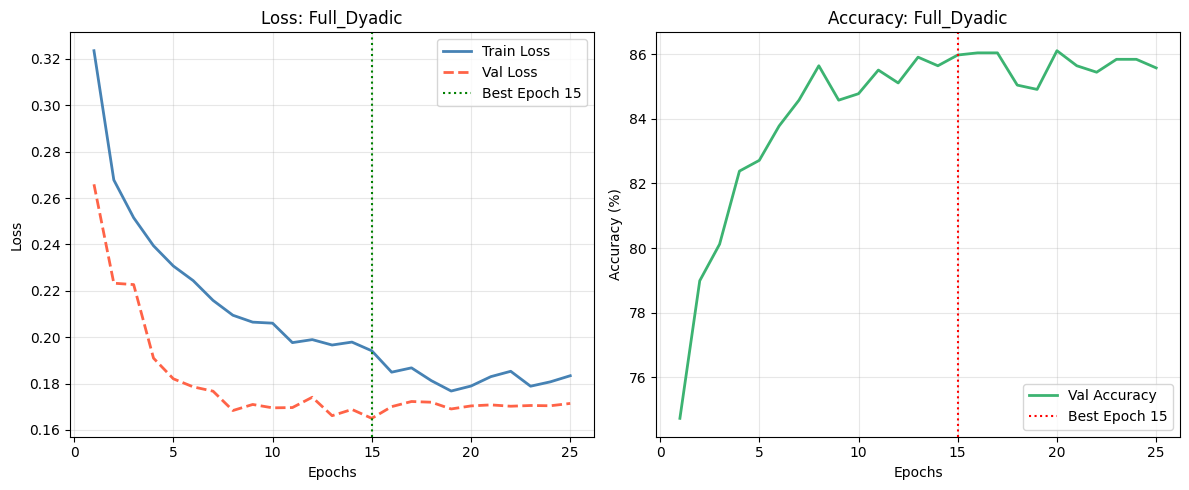

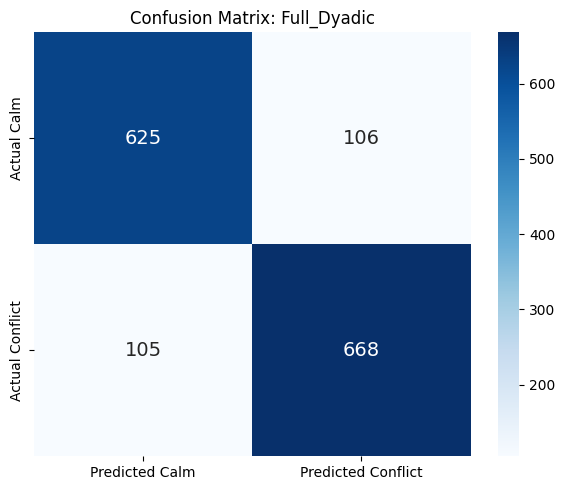

Plots saved to out/plots_v3/
Saved Full_Dyadic weights to out/models/v3/Full_Dyadic_best_weights.pt

STARTING EXPERIMENT: No_Partner
Modalities -> Text: True | Audio: True | SelfVideo: True | PartnerVideo: False

Epoch [01/25] | Train Loss: 0.3263 | Val Loss: 0.2704 | Val Acc: 73.87% | LR: 1.00e-04
Epoch [05/25] | Train Loss: 0.2327 | Val Loss: 0.1925 | Val Acc: 82.51% | LR: 9.33e-05
Epoch [10/25] | Train Loss: 0.2062 | Val Loss: 0.1789 | Val Acc: 84.57% | LR: 6.91e-05
Epoch [15/25] | Train Loss: 0.2049 | Val Loss: 0.1782 | Val Acc: 84.77% | LR: 3.71e-05
Epoch [20/25] | Train Loss: 0.1802 | Val Loss: 0.1739 | Val Acc: 84.77% | LR: 1.03e-05

  Early stopping at epoch 23 (no improvement for 10 epochs).

Restoring best weights from Epoch 13 (Val Loss: 0.1736)

FINAL RESULTS: No_Partner
Accuracy : 84.57%
F1 (macro): 0.8457
--------------------------------------------------
              precision    recall  f1-score   support

    Calm (0)       0.83      0.85      0.84       731
Conflict 

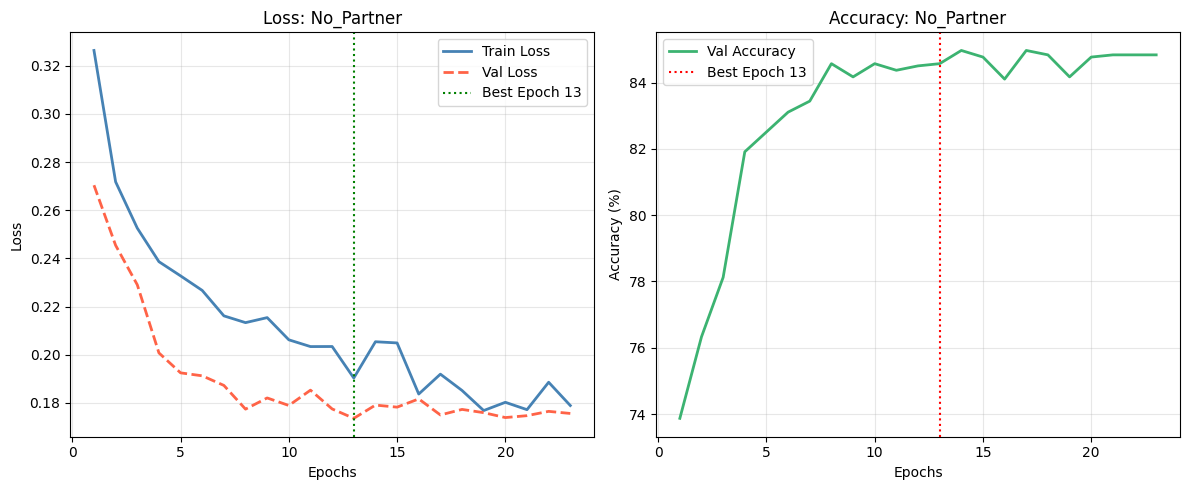

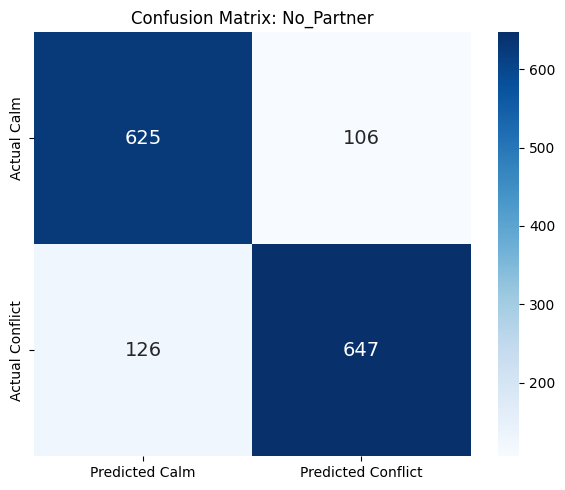

Plots saved to out/plots_v3/
Saved No_Partner weights to out/models/v3/No_Partner_best_weights.pt

STARTING EXPERIMENT: SelfVideo_PartnerVideo
Modalities -> Text: False | Audio: False | SelfVideo: True | PartnerVideo: True

Epoch [01/25] | Train Loss: 0.3288 | Val Loss: 0.3127 | Val Acc: 64.76% | LR: 1.00e-04
Epoch [05/25] | Train Loss: 0.2490 | Val Loss: 0.2343 | Val Acc: 78.19% | LR: 9.33e-05
Epoch [10/25] | Train Loss: 0.2312 | Val Loss: 0.1956 | Val Acc: 82.51% | LR: 6.91e-05
Epoch [15/25] | Train Loss: 0.2245 | Val Loss: 0.2013 | Val Acc: 81.85% | LR: 3.71e-05
Epoch [20/25] | Train Loss: 0.2231 | Val Loss: 0.1927 | Val Acc: 82.98% | LR: 1.03e-05
Epoch [25/25] | Train Loss: 0.2196 | Val Loss: 0.1924 | Val Acc: 83.24% | LR: 0.00e+00

Restoring best weights from Epoch 24 (Val Loss: 0.1889)

FINAL RESULTS: SelfVideo_PartnerVideo
Accuracy : 83.31%
F1 (macro): 0.8331
--------------------------------------------------
              precision    recall  f1-score   support

    Calm (0)   

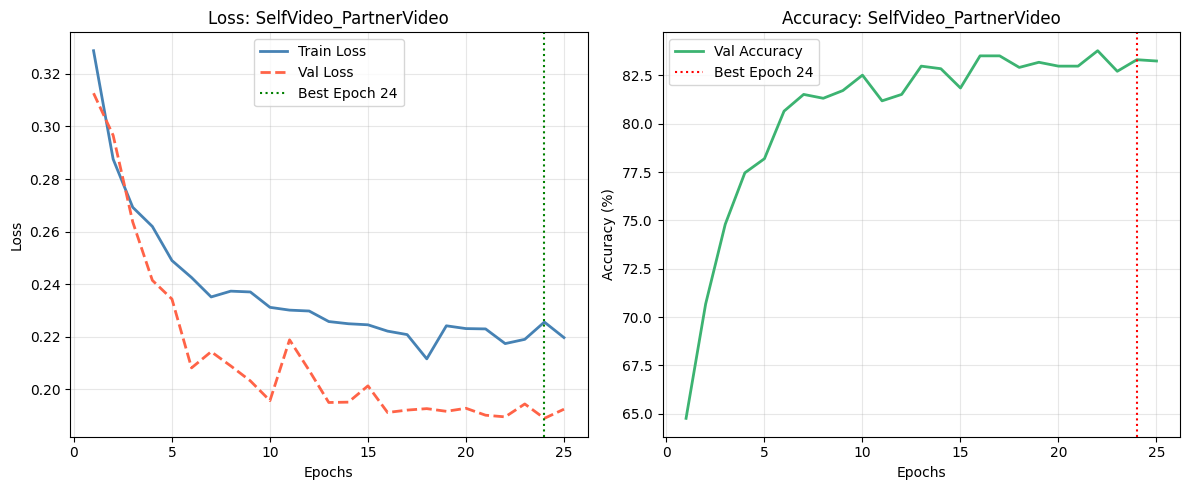

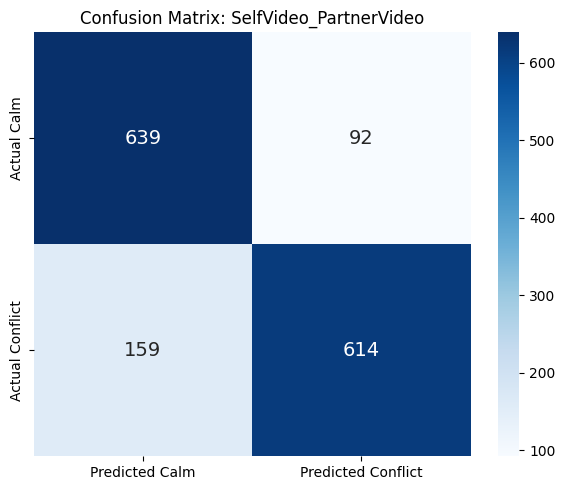

Plots saved to out/plots_v3/
Saved SelfVideo_PartnerVideo weights to out/models/v3/SelfVideo_PartnerVideo_best_weights.pt

STARTING EXPERIMENT: No_SelfVideo
Modalities -> Text: True | Audio: True | SelfVideo: False | PartnerVideo: True

Epoch [01/25] | Train Loss: 0.3375 | Val Loss: 0.3009 | Val Acc: 70.21% | LR: 1.00e-04
Epoch [05/25] | Train Loss: 0.2528 | Val Loss: 0.2310 | Val Acc: 77.33% | LR: 9.33e-05
Epoch [10/25] | Train Loss: 0.2310 | Val Loss: 0.2346 | Val Acc: 77.99% | LR: 6.91e-05

  Early stopping at epoch 14 (no improvement for 10 epochs).

Restoring best weights from Epoch 4 (Val Loss: 0.2231)

FINAL RESULTS: No_SelfVideo
Accuracy : 78.92%
F1 (macro): 0.7888
--------------------------------------------------
              precision    recall  f1-score   support

    Calm (0)       0.79      0.77      0.78       731
Conflict (1)       0.79      0.81      0.80       773

    accuracy                           0.79      1504
   macro avg       0.79      0.79      0.79      

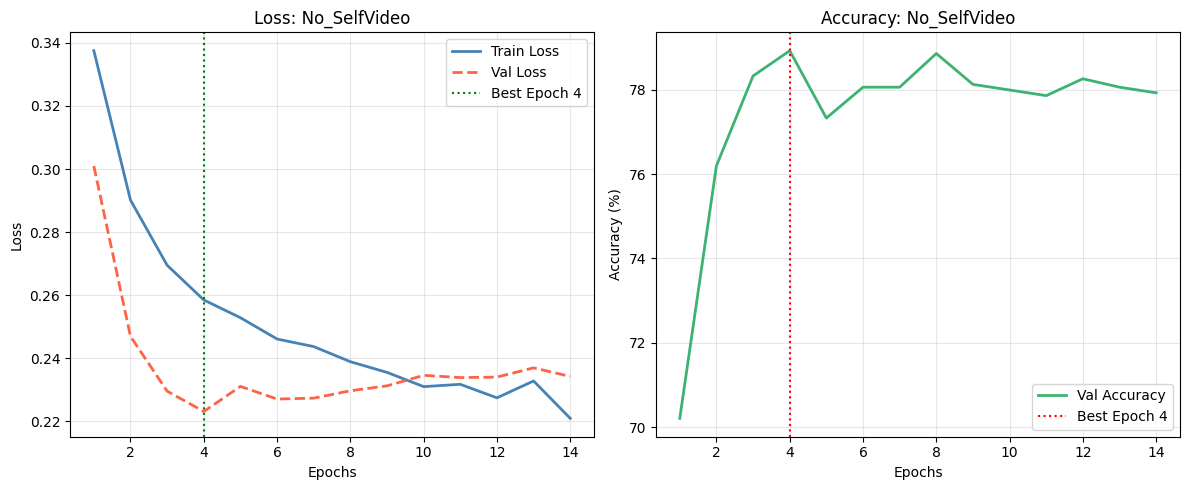

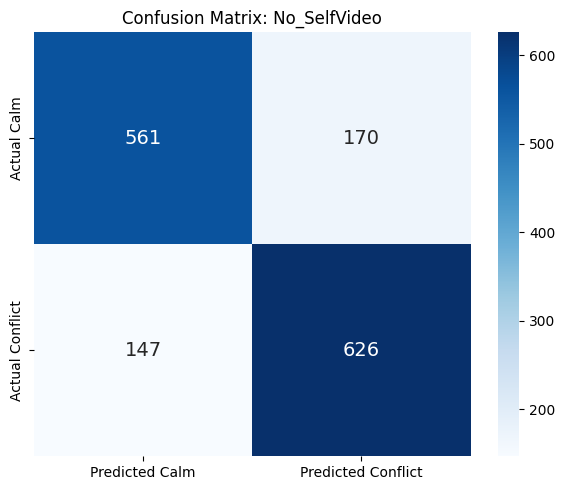

Plots saved to out/plots_v3/
Saved No_SelfVideo weights to out/models/v3/No_SelfVideo_best_weights.pt

STARTING EXPERIMENT: No_Audio
Modalities -> Text: True | Audio: False | SelfVideo: True | PartnerVideo: True

Epoch [01/25] | Train Loss: 0.3326 | Val Loss: 0.3044 | Val Acc: 67.89% | LR: 1.00e-04
Epoch [05/25] | Train Loss: 0.2478 | Val Loss: 0.2164 | Val Acc: 80.12% | LR: 9.33e-05
Epoch [10/25] | Train Loss: 0.2290 | Val Loss: 0.1939 | Val Acc: 82.25% | LR: 6.91e-05
Epoch [15/25] | Train Loss: 0.2198 | Val Loss: 0.1893 | Val Acc: 83.38% | LR: 3.71e-05
Epoch [20/25] | Train Loss: 0.2104 | Val Loss: 0.1833 | Val Acc: 83.51% | LR: 1.03e-05
Epoch [25/25] | Train Loss: 0.2062 | Val Loss: 0.1822 | Val Acc: 83.51% | LR: 0.00e+00

Restoring best weights from Epoch 25 (Val Loss: 0.1822)

FINAL RESULTS: No_Audio
Accuracy : 83.51%
F1 (macro): 0.8348
--------------------------------------------------
              precision    recall  f1-score   support

    Calm (0)       0.84      0.82      0

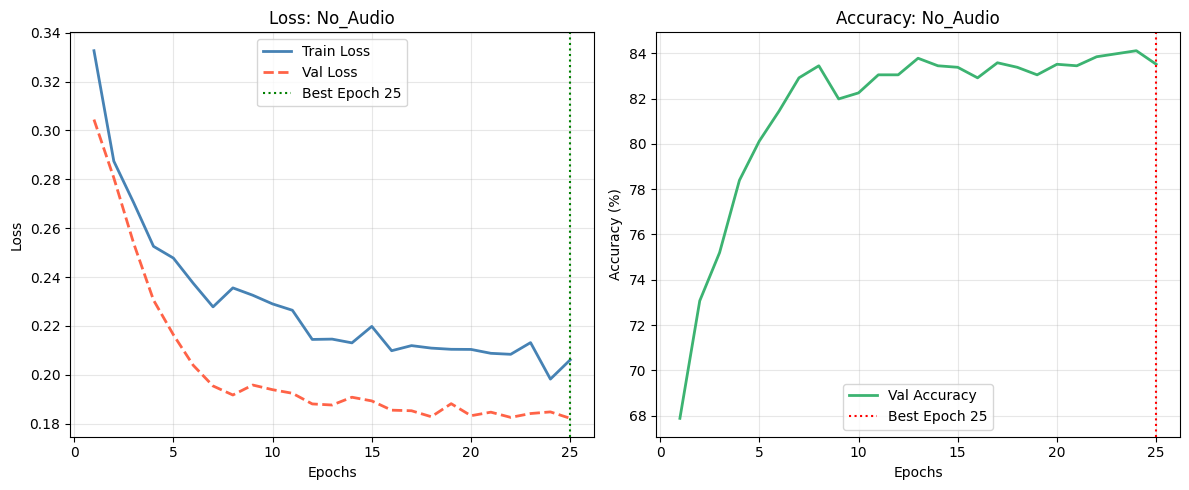

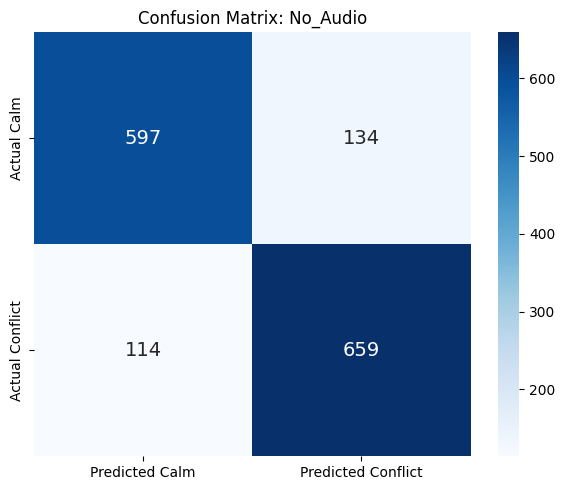

Plots saved to out/plots_v3/
Saved No_Audio weights to out/models/v3/No_Audio_best_weights.pt

STARTING EXPERIMENT: No_Text
Modalities -> Text: False | Audio: True | SelfVideo: True | PartnerVideo: True

Epoch [01/25] | Train Loss: 0.3236 | Val Loss: 0.2636 | Val Acc: 73.14% | LR: 1.00e-04
Epoch [05/25] | Train Loss: 0.2251 | Val Loss: 0.1819 | Val Acc: 83.84% | LR: 9.33e-05
Epoch [10/25] | Train Loss: 0.2120 | Val Loss: 0.1739 | Val Acc: 84.97% | LR: 6.91e-05
Epoch [15/25] | Train Loss: 0.1983 | Val Loss: 0.1690 | Val Acc: 85.44% | LR: 3.71e-05
Epoch [20/25] | Train Loss: 0.1911 | Val Loss: 0.1768 | Val Acc: 84.51% | LR: 1.03e-05

  Early stopping at epoch 24 (no improvement for 10 epochs).

Restoring best weights from Epoch 14 (Val Loss: 0.1690)

FINAL RESULTS: No_Text
Accuracy : 85.04%
F1 (macro): 0.8504
--------------------------------------------------
              precision    recall  f1-score   support

    Calm (0)       0.83      0.86      0.85       731
Conflict (1)       0.

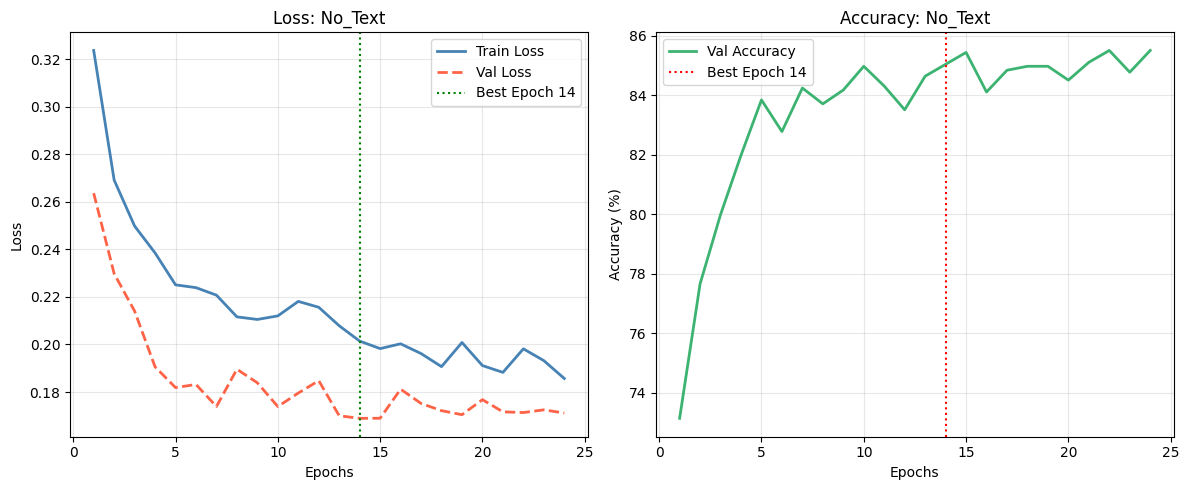

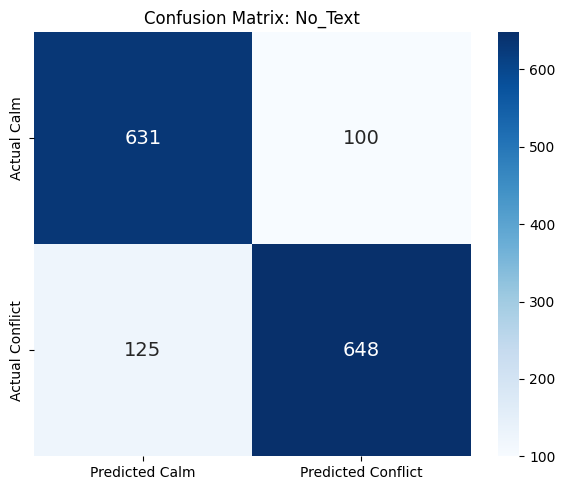

Plots saved to out/plots_v3/
Saved No_Text weights to out/models/v3/No_Text_best_weights.pt

STARTING EXPERIMENT: Only_PartnerVideo
Modalities -> Text: False | Audio: False | SelfVideo: False | PartnerVideo: True

Epoch [01/25] | Train Loss: 0.3519 | Val Loss: 0.3459 | Val Acc: 51.73% | LR: 1.00e-04
Epoch [05/25] | Train Loss: 0.3413 | Val Loss: 0.3421 | Val Acc: 56.72% | LR: 9.33e-05
Epoch [10/25] | Train Loss: 0.3342 | Val Loss: 0.3353 | Val Acc: 57.78% | LR: 6.91e-05
Epoch [15/25] | Train Loss: 0.3337 | Val Loss: 0.3357 | Val Acc: 59.57% | LR: 3.71e-05
Epoch [20/25] | Train Loss: 0.3315 | Val Loss: 0.3324 | Val Acc: 58.84% | LR: 1.03e-05
Epoch [25/25] | Train Loss: 0.3311 | Val Loss: 0.3328 | Val Acc: 58.84% | LR: 0.00e+00

Restoring best weights from Epoch 20 (Val Loss: 0.3324)

FINAL RESULTS: Only_PartnerVideo
Accuracy : 58.84%
F1 (macro): 0.5849
--------------------------------------------------
              precision    recall  f1-score   support

    Calm (0)       0.59      0

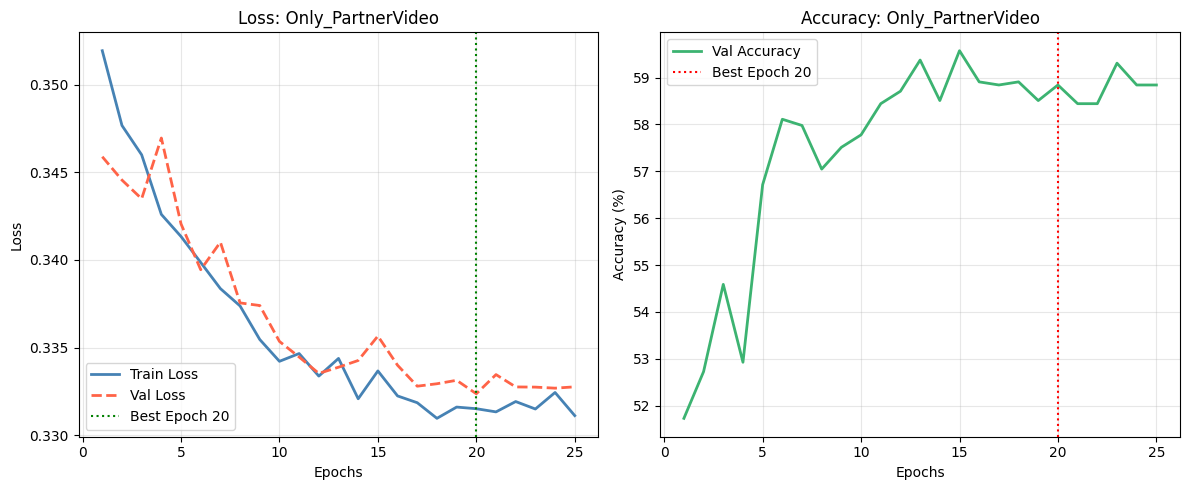

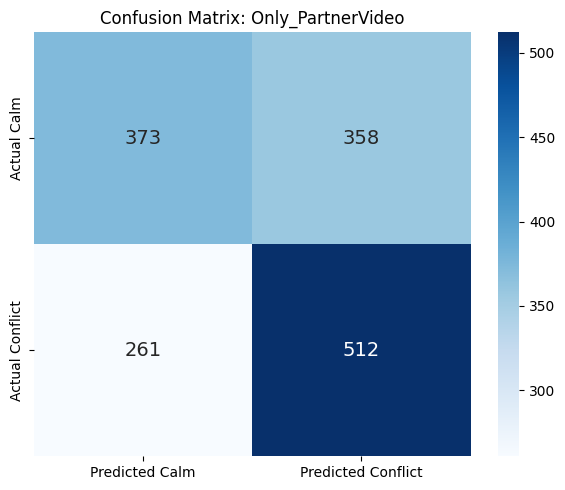

Plots saved to out/plots_v3/
Saved Only_PartnerVideo weights to out/models/v3/Only_PartnerVideo_best_weights.pt

STARTING EXPERIMENT: Only_SelfVideo
Modalities -> Text: False | Audio: False | SelfVideo: True | PartnerVideo: False

Epoch [01/25] | Train Loss: 0.3257 | Val Loss: 0.2998 | Val Acc: 70.61% | LR: 1.00e-04
Epoch [05/25] | Train Loss: 0.2670 | Val Loss: 0.2260 | Val Acc: 77.86% | LR: 9.33e-05
Epoch [10/25] | Train Loss: 0.2446 | Val Loss: 0.2025 | Val Acc: 81.58% | LR: 6.91e-05
Epoch [15/25] | Train Loss: 0.2380 | Val Loss: 0.2022 | Val Acc: 81.91% | LR: 3.71e-05
Epoch [20/25] | Train Loss: 0.2242 | Val Loss: 0.1962 | Val Acc: 82.85% | LR: 1.03e-05
Epoch [25/25] | Train Loss: 0.2345 | Val Loss: 0.1909 | Val Acc: 83.44% | LR: 0.00e+00

Restoring best weights from Epoch 25 (Val Loss: 0.1909)

FINAL RESULTS: Only_SelfVideo
Accuracy : 83.44%
F1 (macro): 0.8343
--------------------------------------------------
              precision    recall  f1-score   support

    Calm (0)    

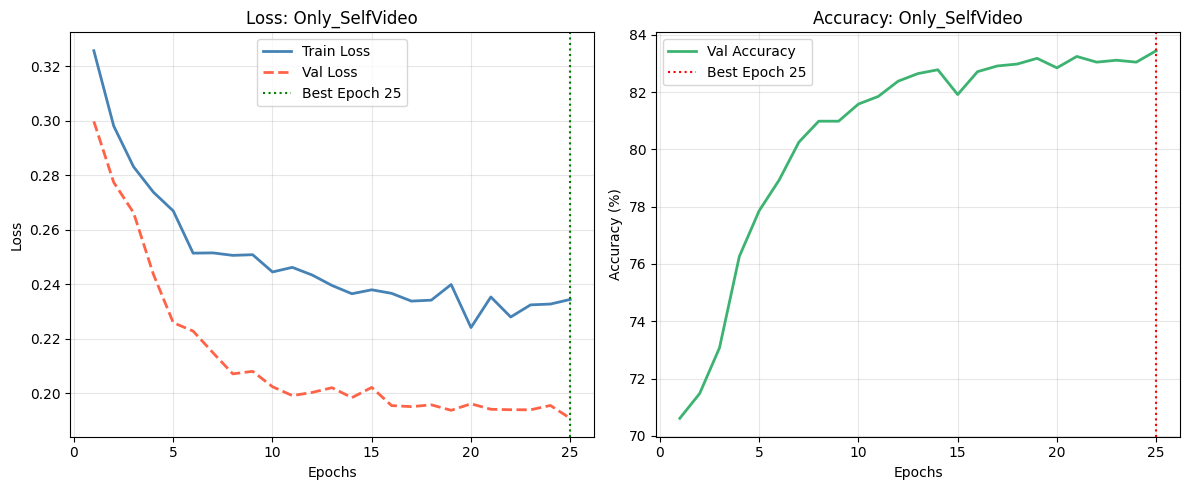

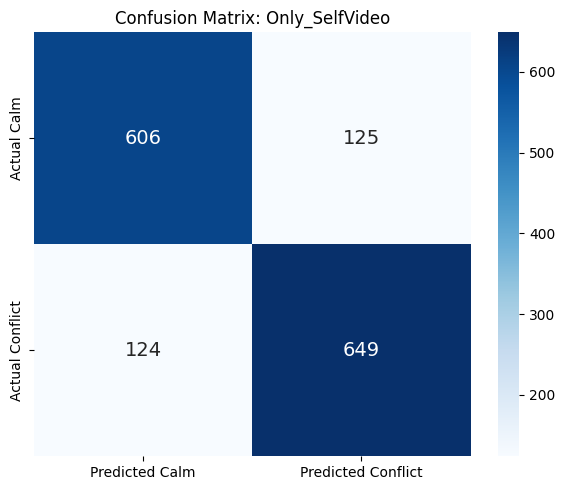

Plots saved to out/plots_v3/
Saved Only_SelfVideo weights to out/models/v3/Only_SelfVideo_best_weights.pt

ABLATION SUMMARY — v2 Dyadic MulT
Experiment                          Acc   F1 (macro)
-----------------------------------------------------------------
Full_Dyadic                      85.97%       0.8596
No_Partner                       84.57%       0.8457 ← v1 equivalent
SelfVideo_PartnerVideo           83.31%       0.8331
No_SelfVideo                     78.92%       0.7888
No_Audio                         83.51%       0.8348
No_Text                          85.04%       0.8504
Only_PartnerVideo                58.84%       0.5849
Only_SelfVideo                   83.44%       0.8343


In [ ]:
# TRAINING LOOP
def train_and_evaluate(
    model,
    train_loader:    DataLoader,
    test_loader:     DataLoader,
    device,
    train_df:        pd.DataFrame,
    epochs:          int   = 25,
    lr:              float = 1e-4,
    use_text:        bool  = True,
    use_audio:       bool  = True,
    use_vs:          bool  = True,
    use_vp:          bool  = True,
    mixup_alpha:     float = 0.2,
    label_smooth:    float = 0.05,
    experiment_name: str   = "Dyadic_MulT",
    plot_dir:        str   = "out/plots_v3",
):
    print(f"\n{'='*55}")
    print(f"STARTING EXPERIMENT: {experiment_name}")
    print(f"Modalities -> Text: {use_text} | Audio: {use_audio} | "
          f"SelfVideo: {use_vs} | PartnerVideo: {use_vp}")
    print(f"{'='*55}\n")

    model = model.to(device)

    # Class-weighted loss (handles ~1:1 balance, but keeps it robust)
    class_counts = train_df["label"].value_counts().sort_index().values
    weights = torch.tensor(1.0 / class_counts.astype(float), dtype=torch.float32)
    weights = (weights / weights.sum()).to(device)

    total_steps  = epochs * len(train_loader)
    warmup_steps = len(train_loader)
    optimizer    = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-3)
    scheduler    = get_cosine_schedule_with_warmup(optimizer, warmup_steps, total_steps)

    train_losses, val_losses, val_accuracies = [], [], []
    best_val_loss  = float("inf")
    best_model_wts = copy.deepcopy(model.state_dict())
    best_epoch     = 1
    patience       = 10
    patience_ctr   = 0

    for epoch in range(epochs):
        # ---- Training ----
        model.train()
        running_loss = 0.0

        for batch_T, batch_A, batch_VS, batch_VP, batch_y in train_loader:
            batch_T  = batch_T.to(device)
            batch_A  = batch_A.to(device)
            batch_VS = batch_VS.to(device)
            batch_VP = batch_VP.to(device)
            batch_y  = batch_y.to(device)

            # MixUp across all 4 streams
            batch_T, batch_A, batch_VS, batch_VP, soft_y = mixup_batch(
                batch_T, batch_A, batch_VS, batch_VP, batch_y, alpha=mixup_alpha
            )

            # Label smoothing
            if label_smooth > 0:
                soft_y = (1 - label_smooth) * soft_y + label_smooth / soft_y.size(1)

            logits = model(batch_T, batch_A, batch_VS, batch_VP,
                           use_text, use_audio, use_vs, use_vp)

            log_probs = F.log_softmax(logits, dim=-1)
            weighted_log = log_probs * weights.unsqueeze(0)
            loss = -(soft_y * weighted_log).sum(dim=-1).mean()

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            scheduler.step()
            running_loss += loss.item()

        epoch_train_loss = running_loss / len(train_loader)
        train_losses.append(epoch_train_loss)

        # ---- Validation ----
        model.eval()
        running_val_loss = 0.0
        val_preds, val_targets = [], []

        with torch.no_grad():
            for batch_T, batch_A, batch_VS, batch_VP, batch_y in test_loader:
                batch_T  = batch_T.to(device)
                batch_A  = batch_A.to(device)
                batch_VS = batch_VS.to(device)
                batch_VP = batch_VP.to(device)
                batch_y  = batch_y.to(device)

                logits = model(batch_T, batch_A, batch_VS, batch_VP,
                               use_text, use_audio, use_vs, use_vp)

                y_onehot = torch.zeros_like(logits).scatter_(1, batch_y.unsqueeze(1), 1.0)
                log_probs = F.log_softmax(logits, dim=-1)
                val_loss  = -(y_onehot * (log_probs * weights.unsqueeze(0))).sum(dim=-1).mean()
                running_val_loss += val_loss.item()

                _, predicted = torch.max(logits, 1)
                val_preds.extend(predicted.cpu().numpy())
                val_targets.extend(batch_y.cpu().numpy())

        epoch_val_loss = running_val_loss / len(test_loader)
        epoch_val_acc  = accuracy_score(val_targets, val_preds)
        val_losses.append(epoch_val_loss)
        val_accuracies.append(epoch_val_acc)

        if (epoch + 1) % 5 == 0 or epoch == 0:
            current_lr = optimizer.param_groups[0]["lr"]
            print(
                f"Epoch [{epoch+1:02d}/{epochs}] | "
                f"Train Loss: {epoch_train_loss:.4f} | "
                f"Val Loss: {epoch_val_loss:.4f} | "
                f"Val Acc: {epoch_val_acc*100:.2f}% | "
                f"LR: {current_lr:.2e}"
            )

        if epoch_val_loss < best_val_loss:
            best_val_loss  = epoch_val_loss
            best_model_wts = copy.deepcopy(model.state_dict())
            best_epoch     = epoch + 1
            patience_ctr   = 0
        else:
            patience_ctr += 1
            if patience_ctr >= patience:
                print(f"\n  Early stopping at epoch {epoch+1} (no improvement for {patience} epochs).")
                break

    print(f"\nRestoring best weights from Epoch {best_epoch} (Val Loss: {best_val_loss:.4f})")
    model.load_state_dict(best_model_wts)

    # ---- Final evaluation ----
    model.eval()
    final_preds, final_targets = [], []
    with torch.no_grad():
        for batch_T, batch_A, batch_VS, batch_VP, batch_y in test_loader:
            logits = model(
                batch_T.to(device), batch_A.to(device),
                batch_VS.to(device), batch_VP.to(device),
                use_text, use_audio, use_vs, use_vp
            )
            _, predicted = torch.max(logits, 1)
            final_preds.extend(predicted.cpu().numpy())
            final_targets.extend(batch_y.numpy())

    best_acc = accuracy_score(final_targets, final_preds)
    f1       = f1_score(final_targets, final_preds, average="macro")

    print("\n" + "="*50)
    print(f"FINAL RESULTS: {experiment_name}")
    print("="*50)
    print(f"Accuracy : {best_acc*100:.2f}%")
    print(f"F1 (macro): {f1:.4f}")
    print("-"*50)
    print(classification_report(
        final_targets, final_preds,
        target_names=["Calm (0)", "Conflict (1)"]
    ))

    # Print learned gates when all 4 streams active
    if use_text and use_audio and use_vs and use_vp:
        gT  = torch.sigmoid(model.gate_T).item()
        gA  = torch.sigmoid(model.gate_A).item()
        gVS = torch.sigmoid(model.gate_VS).item()
        gVP = torch.sigmoid(model.gate_VP).item()
        print(f"Learned modality gates — Text: {gT:.3f} | Audio: {gA:.3f} | "
              f"SelfVideo: {gVS:.3f} | PartnerVideo: {gVP:.3f}")

    # ---- Plots ----
    os.makedirs(plot_dir, exist_ok=True)
    epochs_run = len(train_losses)

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(range(1, epochs_run + 1), train_losses,
             label="Train Loss", color="steelblue", linewidth=2)
    plt.plot(range(1, epochs_run + 1), val_losses,
             label="Val Loss", color="tomato", linewidth=2, linestyle="--")
    plt.axvline(x=best_epoch, color="green", linestyle=":", label=f"Best Epoch {best_epoch}")
    plt.title(f"Loss: {experiment_name}", fontsize=12)
    plt.xlabel("Epochs"); plt.ylabel("Loss")
    plt.legend(); plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(range(1, epochs_run + 1), [a * 100 for a in val_accuracies],
             label="Val Accuracy", color="mediumseagreen", linewidth=2)
    plt.axvline(x=best_epoch, color="red", linestyle=":", label=f"Best Epoch {best_epoch}")
    plt.title(f"Accuracy: {experiment_name}", fontsize=12)
    plt.xlabel("Epochs"); plt.ylabel("Accuracy (%)")
    plt.legend(); plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(plot_dir, f"{experiment_name}_curves.png"), dpi=200)
    try:
        plt.show(block=False); plt.pause(2)
    except Exception:
        pass
    plt.close()

    cm = confusion_matrix(final_targets, final_preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Predicted Calm", "Predicted Conflict"],
                yticklabels=["Actual Calm",    "Actual Conflict"],
                annot_kws={"size": 14})
    plt.title(f"Confusion Matrix: {experiment_name}", fontsize=12)
    plt.tight_layout()
    plt.savefig(os.path.join(plot_dir, f"{experiment_name}_cm.png"), dpi=200)
    try:
        plt.show(block=False); plt.pause(2)
    except Exception:
        pass
    plt.close()

    print(f"Plots saved to {plot_dir}/")
    return best_acc, f1

if __name__ == "__main__":
    set_seed(92)

    # ---- Load dyadic manifest ----
    df = pd.read_csv("out/master_dataset_dyadic.csv")

    # ---- Load pre-extracted embeddings ----
    print("Loading embeddings...")
    text_dict         = torch.load("embeddings/text_sequences_v1.pt",
                                   map_location="cpu", weights_only=True)
    audio_raw = torch.load("embeddings/audio_sequences_v2.pt", map_location="cpu", weights_only=False)
    audio_dict = audio_raw.get("audio_sequences", audio_raw) if isinstance(audio_raw, dict) else audio_raw
    self_video_dict   = torch.load("embeddings/video_self_sequences_v1.pt",
                                   map_location="cpu", weights_only=False)
    partner_video_dict = torch.load("embeddings/video_partner_sequences_v1.pt",
                                    map_location="cpu", weights_only=False)

    dyadic_ids = set(df["sample_id"])
    text_ids   = set(text_dict.keys())
    missing_text = dyadic_ids - text_ids
    if missing_text:
        print(f"WARNING: {len(missing_text)} dyadic sample_ids missing from text embeddings.")
        print("  Re-run text_extraction / audio_extraction with MASTER_CSV pointing to "
              "out/master_dataset_dyadic.csv before running this model.")

    # ---- Group-based split ----
    train_df, test_df = group_split(df, test_size=0.20, seed=42)
    print(f"\nTrain: {len(train_df)} utterances from "
          f"{train_df['file_id'].nunique()} unique videos")
    print(f"Test : {len(test_df)} utterances from "
          f"{test_df['file_id'].nunique()} unique videos")
    print(f"Train label dist: {train_df['label'].value_counts().to_dict()}")
    print(f"Test  label dist: {test_df['label'].value_counts().to_dict()}")

    # ---- Datasets ----
    train_dataset = DyadicSequenceDataset(train_df, text_dict, audio_dict,
                                          self_video_dict, partner_video_dict)
    test_dataset  = DyadicSequenceDataset(test_df,  text_dict, audio_dict,
                                          self_video_dict, partner_video_dict)

    # ---- Auto-detect dims ----
    VIDEO_DIM = next(iter(self_video_dict.values())).shape[-1]
    AUDIO_DIM = next(iter(audio_dict.values())).shape[-1]
    TEXT_DIM  = next(iter(text_dict.values())).shape[-1]
    print(f"\nAuto-detected dimensions -> "
          f"Text: {TEXT_DIM} | Audio: {AUDIO_DIM} | Video: {VIDEO_DIM}")

    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True,
                              num_workers=8, pin_memory=True)
    test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False,
                              num_workers=8, pin_memory=True)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Device: {device}\n")

    # =================================================================
    # ABLATION STUDY — 8 experiments
    #
    # Core research question answered by each experiment:
    #
    #  Exp 1 — Full_Dyadic:
    #     All 4 streams. Headline number for the paper.
    #
    #  Exp 2 — No_Partner (= v1 equivalent on dyadic data):
    #     Isolates the gain from adding the partner stream.
    #     Compare directly with v1's Full_MulT_With_Time (83.44%).
    #     If Exp1 > Exp2 → partner video helps.
    #
    #  Exp 3 — SelfVideo_PartnerVideo (no language):
    #     Pure visual dyadic model. Shows how much the
    #     cross-speaker reaction adds without linguistic context.
    #
    #  Exp 4 — No_SelfVideo:
    #     Text + Audio + Partner only. Measures whether
    #     partner video alone (without self video) is useful.
    #
    #  Exp 5 — No_Audio:
    #     Text + SelfVideo + PartnerVideo. Measures audio contribution
    #     in the full dyadic setting (replaces v1's MulT_No_Audio).
    #
    #  Exp 6 — No_Text:
    #     Audio + SelfVideo + PartnerVideo. Measures text contribution
    #     (replaces v1's MulT_No_Text).
    #
    #  Exp 7 — Only_PartnerVideo:
    #     Partner reaction alone. Lower bound / sanity check:
    #     can the partner's face alone predict conflict?
    #  Exp 8 — Only_SelfVideo
    # =================================================================
    experiments = [
        # (name,                use_T,  use_A,  use_VS, use_VP)
        ("Full_Dyadic",          True,  True,   True,   True),
        ("No_Partner",           True,  True,   True,   False),   
        ("SelfVideo_PartnerVideo", False, False, True,  True),   
        ("No_SelfVideo",         True,  True,   False,  True),
        ("No_Audio",             True,  False,  True,   True),
        ("No_Text",              False, True,   True,   True),
        ("Only_PartnerVideo",    False, False,  False,  True),
        ("Only_SelfVideo",       False, False,  True,  False)
    ]

    save_dir = "out/models/v3"
    os.makedirs(save_dir, exist_ok=True)
    # ------------------------------------------------------------

    results = {}
    for exp_name, use_t, use_a, use_vs, use_vp in experiments:
        model = CalmToConflict_DyadicMulT(
            text_dim=TEXT_DIM, audio_dim=AUDIO_DIM, video_dim=VIDEO_DIM,
            shared_dim=128, num_heads=4
        ).to(device)

        acc, f1 = train_and_evaluate(
            model, train_loader, test_loader, device, train_df,
            epochs=25, lr=1e-4,
            use_text=use_t, use_audio=use_a, use_vs=use_vs, use_vp=use_vp,
            mixup_alpha=0.2, label_smooth=0.05,
            experiment_name=exp_name,
        )
        results[exp_name] = {"accuracy": acc, "f1_macro": f1}

        # --- Save the model's state dictionary ---
        save_path = os.path.join(save_dir, f"{exp_name}_best_weights.pt")
        torch.save(model.state_dict(), save_path)
        print(f"Saved {exp_name} weights to {save_path}")
        # ----------------------------------------------

    # ---- Summary table ----
    print("\n" + "="*65)
    print("ABLATION SUMMARY — v2 Dyadic MulT")
    print("="*65)
    print(f"{'Experiment':<30} {'Acc':>8} {'F1 (macro)':>12}")
    print("-"*65)
    for name, r in results.items():
        marker = " ← v1 equivalent" if name == "No_Partner" else ""
        print(f"{name:<30} {r['accuracy']*100:>7.2f}% {r['f1_macro']:>12.4f}{marker}")
    print("="*65)

### Running one more -- Audio_SelfVideo

Loading embeddings...

Train: 6355 utterances from 427 unique videos
Test : 1504 utterances from 107 unique videos
Train label dist: {0: 3275, 1: 3080}
Test  label dist: {1: 773, 0: 731}
  [Dataset] Skipped 2 samples missing from at least one embedding dict.

Auto-detected dimensions -> Text: 768 | Audio: 768 | Video: 92
Device: cuda


STARTING EXPERIMENT: Audio_SelfVideo
Modalities -> Text: False | Audio: True | SelfVideo: True | PartnerVideo: False

Epoch [01/25] | Train Loss: 0.3154 | Val Loss: 0.2761 | Val Acc: 72.74% | LR: 1.00e-04
Epoch [05/25] | Train Loss: 0.2294 | Val Loss: 0.2042 | Val Acc: 82.45% | LR: 9.33e-05
Epoch [10/25] | Train Loss: 0.2114 | Val Loss: 0.1926 | Val Acc: 84.24% | LR: 6.91e-05
Epoch [15/25] | Train Loss: 0.2063 | Val Loss: 0.1911 | Val Acc: 85.04% | LR: 3.71e-05

  Early stopping at epoch 19 (no improvement for 10 epochs).

Restoring best weights from Epoch 9 (Val Loss: 0.1780)

FINAL RESULTS: Audio_SelfVideo
Accuracy : 85.17%
F1 (macro): 0.8516
---------

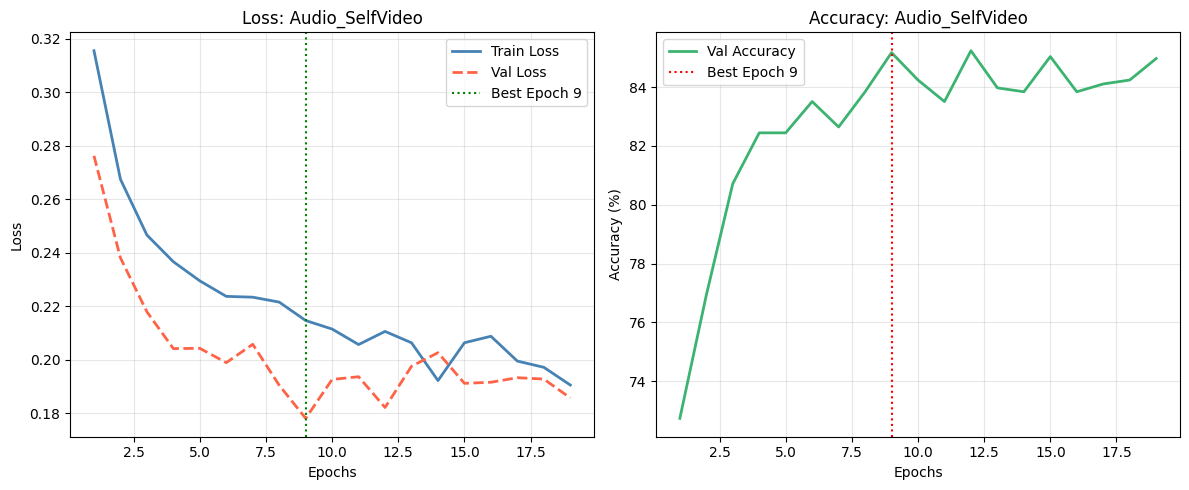

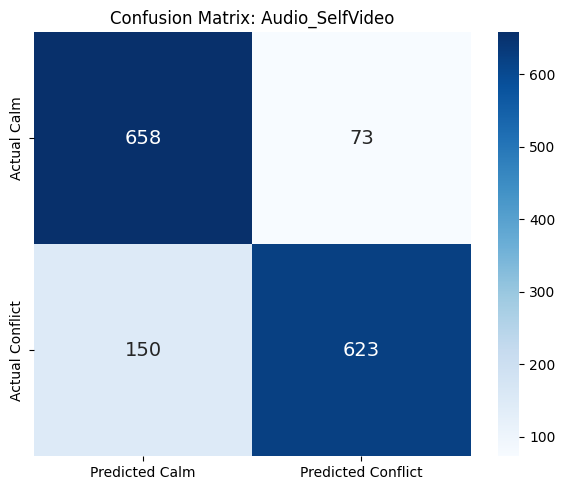

Plots saved to out/plots_v3/
Saved Audio_SelfVideo weights to out/models/v3/Audio_SelfVideo_best_weights.pt

ABLATION SUMMARY — v3 Dyadic MulT
Experiment                          Acc   F1 (macro)
-----------------------------------------------------------------
Audio_SelfVideo                  85.17%       0.8516


In [ ]:
if __name__ == "__main__":
    set_seed(42)

    df = pd.read_csv("out/master_dataset_dyadic.csv")

    print("Loading embeddings...")
    text_dict         = torch.load("embeddings/text_sequences_v1.pt",
                                   map_location="cpu", weights_only=True)
    audio_raw = torch.load("embeddings/audio_sequences_v2.pt", map_location="cpu", weights_only=False)
    audio_dict = audio_raw.get("audio_sequences", audio_raw) if isinstance(audio_raw, dict) else audio_raw
    self_video_dict   = torch.load("embeddings/video_self_sequences_v1.pt",
                                   map_location="cpu", weights_only=False)
    partner_video_dict = torch.load("embeddings/video_partner_sequences_v1.pt",
                                    map_location="cpu", weights_only=False)

    dyadic_ids = set(df["sample_id"])
    text_ids   = set(text_dict.keys())
    missing_text = dyadic_ids - text_ids
    if missing_text:
        print(f"WARNING: {len(missing_text)} dyadic sample_ids missing from text embeddings.")
        print("  Re-run text_extraction / audio_extraction with MASTER_CSV pointing to "
              "out/master_dataset_dyadic.csv before running this model.")

    # ---- Group-based split ----
    train_df, test_df = group_split(df, test_size=0.20, seed=42)
    print(f"\nTrain: {len(train_df)} utterances from "
          f"{train_df['file_id'].nunique()} unique videos")
    print(f"Test : {len(test_df)} utterances from "
          f"{test_df['file_id'].nunique()} unique videos")
    print(f"Train label dist: {train_df['label'].value_counts().to_dict()}")
    print(f"Test  label dist: {test_df['label'].value_counts().to_dict()}")

    # ---- Datasets ----
    train_dataset = DyadicSequenceDataset(train_df, text_dict, audio_dict,
                                          self_video_dict, partner_video_dict)
    test_dataset  = DyadicSequenceDataset(test_df,  text_dict, audio_dict,
                                          self_video_dict, partner_video_dict)

    # ---- Auto-detect dims ----
    VIDEO_DIM = next(iter(self_video_dict.values())).shape[-1]
    AUDIO_DIM = next(iter(audio_dict.values())).shape[-1]
    TEXT_DIM  = next(iter(text_dict.values())).shape[-1]
    print(f"\nAuto-detected dimensions -> "
          f"Text: {TEXT_DIM} | Audio: {AUDIO_DIM} | Video: {VIDEO_DIM}")

    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True,
                              num_workers=8, pin_memory=True)
    test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False,
                              num_workers=8, pin_memory=True)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Device: {device}\n")

    experiments = [
        # (name,                use_T,  use_A,  use_VS, use_VP)
        ("Audio_SelfVideo",    False, True,  True,  False),
    ]

    save_dir = "out/models/v3"
    os.makedirs(save_dir, exist_ok=True)

    results = {}
    for exp_name, use_t, use_a, use_vs, use_vp in experiments:
        model = CalmToConflict_DyadicMulT(
            text_dim=TEXT_DIM, audio_dim=AUDIO_DIM, video_dim=VIDEO_DIM,
            shared_dim=128, num_heads=4
        ).to(device)

        acc, f1 = train_and_evaluate(
            model, train_loader, test_loader, device, train_df,
            epochs=25, lr=1e-4,
            use_text=use_t, use_audio=use_a, use_vs=use_vs, use_vp=use_vp,
            mixup_alpha=0.2, label_smooth=0.05,
            experiment_name=exp_name,
        )
        results[exp_name] = {"accuracy": acc, "f1_macro": f1}

        save_path = os.path.join(save_dir, f"{exp_name}_best_weights.pt")
        torch.save(model.state_dict(), save_path)
        print(f"Saved {exp_name} weights to {save_path}")

    # ---- Summary table ----
    print("\n" + "="*65)
    print("ABLATION SUMMARY — v3 Dyadic MulT")
    print("="*65)
    print(f"{'Experiment':<30} {'Acc':>8} {'F1 (macro)':>12}")
    print("-"*65)
    for name, r in results.items():
        marker = " ← v1 equivalent" if name == "No_Partner" else ""
        print(f"{name:<30} {r['accuracy']*100:>7.2f}% {r['f1_macro']:>12.4f}{marker}")
    print("="*65)

# Visual Feature Ablation

## Spliting Video Features

In [ ]:
import os
import json
import math
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from tqdm import tqdm
from concurrent.futures import ProcessPoolExecutor, as_completed

In [ ]:
MASTER_CSV   = "out/master_dataset_dyadic.csv"
OUTPUT_SELF  = "embeddings/video_self_sequences_v1.pt"
OUTPUT_PART  = "embeddings/video_partner_sequences_v1.pt"
OUTPUT_DIMS  = "embeddings/video_feature_dims.json"

ORIGINAL_FPS = 30
TARGET_FPS   = 5
NUM_WORKERS  = 4

In [ ]:
def _load_npz_features(npz_path: str):
    """
    Loads FAU + head + gaze + body from an NPZ file.

    Returns
    -------
    matrix      : np.ndarray [num_frames, D_total]
    dim_info    : dict with fau_dim, head_dim, gaze_dim, body_dim
                  (None if load fails)
    """
    try:
        d = np.load(npz_path, allow_pickle=True)

        if   'movement_v4:FAUValue' in d.files: au = d['movement_v4:FAUValue']
        elif 'movement:FAUValue'    in d.files: au = d['movement:FAUValue']
        else: return None, None

        n = au.shape[0]

        if   'movement_v4:head_encodings' in d.files: head = d['movement_v4:head_encodings']
        elif 'movement:head_encodings'    in d.files: head = d['movement:head_encodings']
        else: head = np.zeros((n, 6))

        if   'movement_v4:gaze_encodings' in d.files: gaze = d['movement_v4:gaze_encodings']
        elif 'movement:gaze_encodings'    in d.files: gaze = d['movement:gaze_encodings']
        else: gaze = np.zeros((n, 6))

        if   'smplh:body_pose' in d.files: body = d['smplh:body_pose']
        else: body = np.zeros((n, 63))

        # Flatten [Frames, Joints, 3] → [Frames, Joints*3]
        au   = au.reshape(n, -1)
        head = head.reshape(n, -1)
        gaze = gaze.reshape(n, -1)
        body = body.reshape(n, -1)

        min_f = min(au.shape[0], head.shape[0], gaze.shape[0], body.shape[0])
        matrix = np.column_stack([
            au[:min_f], head[:min_f], gaze[:min_f], body[:min_f]
        ])

        dim_info = {
            "fau_dim":  au.shape[1],
            "head_dim": head.shape[1],
            "gaze_dim": gaze.shape[1],
            "body_dim": body.shape[1],
        }
        return matrix, dim_info

    except Exception:
        return None, None

In [ ]:
def process_single_file(args):
    self_npz, partner_npz, group_df, max_video_len = args
    self_results    = {}
    partner_results = {}

    self_matrix, dim_info = _load_npz_features(self_npz)
    if self_matrix is None:
        return {}, {}, None

    if partner_npz and os.path.exists(partner_npz):
        partner_matrix, _ = _load_npz_features(partner_npz)
        if partner_matrix is None:
            partner_matrix = np.zeros_like(self_matrix)
        min_len        = min(self_matrix.shape[0], partner_matrix.shape[0])
        self_matrix    = self_matrix[:min_len]
        partner_matrix = partner_matrix[:min_len]
    else:
        partner_matrix = np.zeros_like(self_matrix)

    step      = ORIGINAL_FPS // TARGET_FPS   # 6
    offset_fr = int(2.0 * ORIGINAL_FPS)      # 60 frames = 2 sec reaction window

    def process_clip(clip):
        if step > 0 and len(clip) > step:
            clip = clip[::step]
        t = torch.tensor(clip, dtype=torch.float32)
        cur = t.shape[0]
        if cur > max_video_len:
            t = t[:max_video_len]
        elif cur < max_video_len:
            t = F.pad(t, (0, 0, 0, max_video_len - cur), "constant", 0)
        return t

    for _, row in group_df.iterrows():
        sid      = row['sample_id']
        start_fr = int(row['start_sec'] * ORIGINAL_FPS)
        end_fr   = min(int(row['end_sec'] * ORIGINAL_FPS), self_matrix.shape[0])

        self_results[sid]    = process_clip(self_matrix[start_fr:end_fr])
        partner_end          = min(end_fr + offset_fr, partner_matrix.shape[0])
        partner_results[sid] = process_clip(partner_matrix[end_fr:partner_end])

    return self_results, partner_results, dim_info

In [ ]:
def extract_dyadic_video_sequences():
    df = pd.read_csv(MASTER_CSV)
    p95_duration  = df['duration_sec'].quantile(0.95)
    MAX_VIDEO_LEN = math.ceil(p95_duration * TARGET_FPS)
    print(f"95th percentile duration : {p95_duration:.2f}s")
    print(f"MAX_VIDEO_LEN            : {MAX_VIDEO_LEN} frames @ {TARGET_FPS} fps")

    # ---- Checkpoint resume ----
    if os.path.exists(OUTPUT_SELF) and os.path.exists(OUTPUT_PART):
        self_dict    = torch.load(OUTPUT_SELF, weights_only=False)
        partner_dict = torch.load(OUTPUT_PART, weights_only=False)
        done         = set(self_dict.keys())
        df_todo      = df[~df['sample_id'].isin(done)]
        print(f"Resuming — {len(done)} done, {len(df_todo)} remaining.")
    else:
        self_dict    = {}
        partner_dict = {}
        df_todo      = df

    global_dim_info = None   # will be set from the first successful file

    if len(df_todo) > 0:
        tasks = []
        for self_npz, group in df_todo.groupby('npz_path'):
            partner_npz = group['partner_npz_path'].iloc[0]
            if pd.isna(partner_npz) or partner_npz == "":
                partner_npz = ""
            tasks.append((self_npz, partner_npz, group, MAX_VIDEO_LEN))

        print(f"\nGrouped into {len(tasks)} unique speaker files.")
        print(f"Starting multi-core extraction ({NUM_WORKERS} workers)...")

        save_interval = 50
        with ProcessPoolExecutor(max_workers=NUM_WORKERS) as executor:
            futures = {executor.submit(process_single_file, t): t for t in tasks}
            for i, future in enumerate(tqdm(as_completed(futures),
                                            total=len(futures),
                                            desc="Processing files")):
                try:
                    s_res, p_res, dim_info = future.result()
                    self_dict.update(s_res)
                    partner_dict.update(p_res)
                    if dim_info is not None and global_dim_info is None:
                        global_dim_info = dim_info
                except Exception as e:
                    print(f"  Worker error: {e}")

                if (i + 1) % save_interval == 0:
                    torch.save(self_dict,    OUTPUT_SELF)
                    torch.save(partner_dict, OUTPUT_PART)

        torch.save(self_dict,    OUTPUT_SELF)
        torch.save(partner_dict, OUTPUT_PART)
    else:
        print("Embeddings already complete — generating metadata only.")

    # ---- Fallback: if global_dim_info was never set (all workers failed,
    #      or df_todo was empty), scan the CSV for any readable NPZ file. ----
    if global_dim_info is None:
        print("Discovering feature dims from CSV NPZ paths...")
        for npz_path in df['npz_path'].dropna().unique():
            _, info = _load_npz_features(npz_path)
            if info is not None:
                global_dim_info = info
                print(f"  Dims read from: {npz_path}")
                break
        if global_dim_info is None:
            print("ERROR: Could not read feature dims from any NPZ file in the CSV.")
            print("       Check that npz_path column in the CSV points to accessible files.")

    # ---- Save feature boundary metadata ----
    if global_dim_info is not None:
        fau_end  = global_dim_info['fau_dim']
        head_end = fau_end  + global_dim_info['head_dim']
        gaze_end = head_end + global_dim_info['gaze_dim']
        body_end = gaze_end + global_dim_info['body_dim']

        meta = {
            **global_dim_info,
            "total_dim":  body_end,
            "fau_slice":  [0,        fau_end],
            "head_slice": [fau_end,  head_end],
            "gaze_slice": [head_end, gaze_end],
            "body_slice": [gaze_end, body_end],
        }
        with open(OUTPUT_DIMS, "w") as f:
            json.dump(meta, f, indent=2)
        print(f"\nFeature boundary metadata → {OUTPUT_DIMS}")
        print(f"  FAU : dim={meta['fau_dim']:>3}  slice [{meta['fau_slice'][0]:>2}:{meta['fau_slice'][1]:>3}]")
        print(f"  Head: dim={meta['head_dim']:>3}  slice [{meta['head_slice'][0]:>2}:{meta['head_slice'][1]:>3}]")
        print(f"  Gaze: dim={meta['gaze_dim']:>3}  slice [{meta['gaze_slice'][0]:>2}:{meta['gaze_slice'][1]:>3}]")
        print(f"  Body: dim={meta['body_dim']:>3}  slice [{meta['body_slice'][0]:>2}:{meta['body_slice'][1]:>3}]")

    print(f"\nSaved self    embeddings → {OUTPUT_SELF}")
    print(f"Saved partner embeddings → {OUTPUT_PART}")
    print(f"Total samples in self    : {len(self_dict)}")
    print(f"Total samples in partner : {len(partner_dict)}")

    n_zero = sum(
        1 for v in partner_dict.values() if v.abs().sum().item() == 0
    )
    print(f"Partner samples all-zeros (no partner): {n_zero}")


if __name__ == "__main__":
    extract_dyadic_video_sequences()

95th percentile duration : 12.93s
MAX_VIDEO_LEN            : 65 frames @ 5 fps
Resuming — 7857 done, 2 remaining.

Grouped into 1 unique speaker files.
Starting multi-core extraction (4 workers)...


Processing files: 100%|██████████| 1/1 [00:00<00:00, 80.45it/s]


Discovering feature dims from CSV NPZ paths...
  Dims read from: /project2/msoleyma_1026/CalmToConflict/data/improvised/train/0020/0026/V00_S0970_I00001219_P0602A.npz

Feature boundary metadata → embeddings/video_feature_dims.json
  FAU : dim= 24  slice [ 0: 24]
  Head: dim=  3  slice [24: 27]
  Gaze: dim=  2  slice [27: 29]
  Body: dim= 63  slice [29: 92]

Saved self    embeddings → embeddings/video_self_sequences_v1.pt
Saved partner embeddings → embeddings/video_partner_sequences_v1.pt
Total samples in self    : 7857
Total samples in partner : 7857
Partner samples all-zeros (no partner): 57


## Visual Feature Ablation Model

### Imports and Random Seed

In [ ]:
import os
import json
import random
import copy
import math

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix
)
from sklearn.model_selection import GroupShuffleSplit

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

### FEATURE BOUNDARY LOADING

In [ ]:
def load_feature_dims(json_path: str = "embeddings/video_feature_dims.json") -> dict:
    """
    Loads the feature boundary dict produced by video_extraction_v2.py.
    Returns slices as Python slices for direct tensor indexing.

    Example output:
        {
          'fau':  (0, 24),
          'head': (24, 30),
          'gaze': (30, 36),
          'body': (36, 99),
        }
    """
    if not os.path.exists(json_path):
        raise FileNotFoundError(
            f"{json_path} not found.\n"
            "Run video_extraction_v2.py first to generate feature boundary metadata."
        )
    with open(json_path) as f:
        meta = json.load(f)

    return {
        "fau":  tuple(meta["fau_slice"]),
        "head": tuple(meta["head_slice"]),
        "gaze": tuple(meta["gaze_slice"]),
        "body": tuple(meta["body_slice"]),
    }

### GROUP-BASED SPLIT

In [ ]:
def group_split(df: pd.DataFrame, test_size: float = 0.20, seed: int = 42):
    gss    = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=seed)
    groups = df["file_id"].values
    train_idx, test_idx = next(gss.split(df, groups=groups))
    return df.iloc[train_idx].reset_index(drop=True), df.iloc[test_idx].reset_index(drop=True)

### DATASET (split video into 4 sub-streams at load time)

In [ ]:
class VisualAblationDataset(Dataset):
    """
    Returns pre-split video sub-streams so the model can ablate them
    without any per-epoch slicing overhead.

    Items returned: (vs_fau, vs_head, vs_gaze, vs_body,
                     vp_fau, vp_head, vp_gaze, vp_body, label)
    """

    def __init__(self, df,
                 self_video_dict, partner_video_dict,
                 feature_slices: dict):
        self.samples = []
        missing = 0
        fs = feature_slices   # shorthand

        for _, row in df.iterrows():
            sid = row["sample_id"]
            if sid not in self_video_dict:
                missing += 1
                continue

            vs = self_video_dict[sid]                                    # [T, D]
            vp = partner_video_dict.get(sid, torch.zeros_like(vs))

            self.samples.append({
                "label":   int(row["label"]),
                # --- speaker sub-streams ---
                "vs_fau":  vs[:, fs["fau"][0]:fs["fau"][1]],
                "vs_head": vs[:, fs["head"][0]:fs["head"][1]],
                "vs_gaze": vs[:, fs["gaze"][0]:fs["gaze"][1]],
                "vs_body": vs[:, fs["body"][0]:fs["body"][1]],
                # --- partner sub-streams ---
                "vp_fau":  vp[:, fs["fau"][0]:fs["fau"][1]],
                "vp_head": vp[:, fs["head"][0]:fs["head"][1]],
                "vp_gaze": vp[:, fs["gaze"][0]:fs["gaze"][1]],
                "vp_body": vp[:, fs["body"][0]:fs["body"][1]],
            })

        if missing:
            print(f"  [Dataset] Skipped {missing} samples missing from video dicts.")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        item = self.samples[idx]
        return (
            item["vs_fau"].clone().float(),
            item["vs_head"].clone().float(),
            item["vs_gaze"].clone().float(),
            item["vs_body"].clone().float(),
            item["vp_fau"].clone().float(),
            item["vp_head"].clone().float(),
            item["vp_gaze"].clone().float(),
            item["vp_body"].clone().float(),
            torch.tensor(item["label"], dtype=torch.long),
        )

### MIXUP (8 sub-streams)

In [ ]:
def mixup_batch(streams: list, y: torch.Tensor, alpha: float = 0.2):
    """
    streams : list of 8 tensors [B, T, D_sub]
    Returns mixed streams (list) and soft labels.
    """
    B = y.size(0)
    NC = 2

    if alpha <= 0:
        y_soft = torch.zeros(B, NC, device=y.device).scatter_(1, y.unsqueeze(1), 1.0)
        return streams, y_soft

    lam = np.random.beta(alpha, alpha)
    lam = max(lam, 1 - lam)
    idx = torch.randperm(B, device=streams[0].device)

    mixed = [lam * s + (1 - lam) * s[idx] for s in streams]

    y_a    = torch.zeros(B, NC, device=y.device).scatter_(1, y.unsqueeze(1), 1.0)
    y_b    = torch.zeros(B, NC, device=y.device).scatter_(1, y[idx].unsqueeze(1), 1.0)
    y_soft = lam * y_a + (1 - lam) * y_b
    return mixed, y_soft

### Model

In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, dropout: float = 0.1, max_len: int = 2000):
        super().__init__()
        self.dropout  = nn.Dropout(p=dropout)
        position      = torch.arange(max_len).unsqueeze(1)
        div_term      = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        pe            = torch.zeros(max_len, 1, d_model)
        pe[:, 0, 0::2] = torch.sin(position * div_term)
        pe[:, 0, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe)

    def forward(self, x):
        x = x.transpose(0, 1)
        x = x + self.pe[:x.size(0)]
        return self.dropout(x.transpose(0, 1))


class AttentionPool(nn.Module):
    def __init__(self, dim: int):
        super().__init__()
        self.score = nn.Linear(dim, 1)

    def forward(self, x):
        w = torch.softmax(self.score(x), dim=1)
        return (x * w).sum(dim=1)


class CrossModalAttentionBlock(nn.Module):
    def __init__(self, embed_dim: int, num_heads: int, dropout: float = 0.2):
        super().__init__()
        self.cross_attn = nn.MultiheadAttention(
            embed_dim=embed_dim, num_heads=num_heads,
            dropout=dropout, batch_first=True
        )
        self.norm1   = nn.LayerNorm(embed_dim)
        self.norm2   = nn.LayerNorm(embed_dim)
        self.ffn     = nn.Sequential(
            nn.Linear(embed_dim, embed_dim * 2), nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(embed_dim * 2, embed_dim),
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, query, key_value):
        attn_out, _ = self.cross_attn(query=query, key=key_value, value=key_value)
        x = self.norm1(query + self.dropout(attn_out))
        x = self.norm2(x + self.dropout(self.ffn(x)))
        return x


In [ ]:
"""
CalmToConflict MulT — Visual Feature Ablation
=================================================

Starting point
--------------
v1's ablation showed that SelfVideo + PartnerVideo (83.31%) is a very 
strong configuration.

Research question answered here
--------------------------------
Within the visual modality (FAU=24, head=3, gaze=2, body=63 dims),
WHICH feature type(s) drive the cross-speaker gain?

Approach
--------
No re-extraction is needed. The combined video tensors [T, D_total] have
features concatenated in a fixed order: [FAU | head | gaze | body].
The boundary indices are read from embeddings/video_feature_dims.json
(generated by video_extraction_v2.py).

At dataset time, each tensor is sliced into 4 sub-tensors. The model
receives separate projection heads for each, processes them in parallel,
and the ablation flag masks entire sub-streams to zero before projection.

Model architecture
------------------
Same cross-speaker MulT as v1, but the "video_self" and "video_partner"
streams are each split into 4 sub-streams before projection:
  VS_FAU, VS_head, VS_gaze, VS_body
  VP_FAU, VP_head, VP_gaze, VP_body

All 8 sub-streams share the same CrossModalAttentionBlock instances
(weight sharing via stream type), with the same gating mechanism.

Ablation experiments (10 total)
--------------------------------
 1. Full_Visual_Dyadic       — all 8 sub-streams (sanity check vs v2)
 2. FAU_Only                 — VS_FAU + VP_FAU
 3. Head_Only                — VS_head + VP_head
 4. Gaze_Only                — VS_gaze + VP_gaze
 5. Body_Only                — VS_body + VP_body
 6. FAU_Head                 — FAU + head (face+orientation)
 7. FAU_Gaze                 — FAU + gaze (face+eye contact)
 8. FAU_Body                 — FAU + body (face+posture)
 9. NoBody                   — FAU + head + gaze (all face streams)
10. Body_Partner_Only        — VS_body + VP_FAU  (posture self, face partner)

The last experiment is theoretically motivated: body posture of the speaker
(VS_body) and partner facial expression (VP_FAU) may together form the
strongest dyadic conflict signal.
"""

class VisualDyadicMulT(nn.Module):
    """
    Processes up to 8 visual sub-streams (4 speaker + 4 partner).
    Each sub-stream has its own projection layer.
    Cross-speaker attention: VS_i attends to VP_i for each active feature i.
    Intra-speaker attention: Each VS_i attends to all other active VS_j.

    Classifier input: concat of all active pooled sub-stream vectors.
    Classifier size adapts dynamically to the number of active streams.
    """

    STREAM_KEYS = ["fau", "head", "gaze", "body"]

    def __init__(
        self,
        feature_dims: dict,   # {"fau": D_fau, "head": D_head, ...}
        shared_dim:   int   = 64,
        num_heads:    int   = 4,
        num_classes:  int   = 2,
        dropout:      float = 0.2,
    ):
        super().__init__()
        self.shared_dim   = shared_dim
        self.feature_dims = feature_dims
        self.keys         = self.STREAM_KEYS

        # --- Per-sub-stream projection (speaker and partner share weights) ---
        self.proj = nn.ModuleDict({
            k: nn.Conv1d(feature_dims[k], shared_dim, kernel_size=1)
            for k in self.keys
        })

        # --- Positional encoding (shared) ---
        self.pos_encoder = PositionalEncoding(d_model=shared_dim, dropout=dropout)

        # --- Intra-speaker cross-feature attention (VS_i ← VS_j) ---
        # One block per (query_key, kv_key) ordered pair, shared across speakers
        self.intra_attn = nn.ModuleDict({
            f"{q}_{kv}": CrossModalAttentionBlock(shared_dim, num_heads, dropout)
            for q  in self.keys
            for kv in self.keys
            if q != kv
        })

        # --- Cross-speaker attention: VS_i ← VP_i (same feature type) ---
        self.cross_self_to_partner = nn.ModuleDict({
            k: CrossModalAttentionBlock(shared_dim, num_heads, dropout)
            for k in self.keys
        })
        self.cross_partner_to_self = nn.ModuleDict({
            k: CrossModalAttentionBlock(shared_dim, num_heads, dropout)
            for k in self.keys
        })

        # --- Attention pooling and gating (speaker + partner, per feature) ---
        self.pool_vs = nn.ModuleDict({k: AttentionPool(shared_dim) for k in self.keys})
        self.pool_vp = nn.ModuleDict({k: AttentionPool(shared_dim) for k in self.keys})
        self.gate_vs = nn.ParameterDict({k: nn.Parameter(torch.ones(1)) for k in self.keys})
        self.gate_vp = nn.ParameterDict({k: nn.Parameter(torch.ones(1)) for k in self.keys})

        # --- Classifier (size depends on active streams, built dynamically) ---
        # Max possible: 8 streams × shared_dim
        self._max_fused_dim = shared_dim * len(self.keys) * 2
        self.classifier_hidden = nn.Sequential(
            nn.Linear(self._max_fused_dim, 256), nn.BatchNorm1d(256), nn.GELU(), nn.Dropout(0.4),
            nn.Linear(256, 128),                 nn.GELU(),            nn.Dropout(0.3),
        )
        self.classifier_head = nn.Linear(128, num_classes)

        # For dynamic fused dim, we project any active combination to the fixed max_fused_dim
        self.input_proj = nn.Linear(self._max_fused_dim, self._max_fused_dim)

    def forward(
        self,
        sub_streams: dict,  # {"vs_fau": tensor, "vs_head": ..., ..., "vp_fau": ..., ...}
        active_vs:   set,   # e.g. {"fau", "body"}
        active_vp:   set,   # e.g. {"fau"}
    ) -> torch.Tensor:
        B   = next(iter(sub_streams.values())).size(0)
        dev = next(iter(sub_streams.values())).device
        D   = self.shared_dim

        def _encode(x, key):
            out = self.proj[key](x.transpose(1, 2)).transpose(1, 2)
            return self.pos_encoder(out)

        # --- Project and encode active sub-streams ---
        enc_vs = {
            k: _encode(sub_streams[f"vs_{k}"], k)
            for k in active_vs
        }
        enc_vp = {
            k: _encode(sub_streams[f"vp_{k}"], k)
            for k in active_vp
        }

        # --- Intra-speaker: each VS_i attends to all other active VS_j ---
        out_vs = {k: enc_vs[k].clone() for k in active_vs}
        for q_key in active_vs:
            for kv_key in active_vs:
                if q_key != kv_key:
                    block_key = f"{q_key}_{kv_key}"
                    out_vs[q_key] = self.intra_attn[block_key](out_vs[q_key], enc_vs[kv_key])

        # --- Cross-speaker: VS_i ← VP_i and VP_i ← VS_i ---
        out_vp = {k: enc_vp[k].clone() for k in active_vp}
        for k in active_vs:
            if k in active_vp:
                out_vs[k] = self.cross_self_to_partner[k](out_vs[k], enc_vp[k])
        for k in active_vp:
            if k in active_vs:
                out_vp[k] = self.cross_partner_to_self[k](out_vp[k], enc_vs[k])

        # --- Pool and gate ---
        pooled_parts = []
        for k in self.keys:
            if k in active_vs:
                g  = torch.sigmoid(self.gate_vs[k])
                pv = self.pool_vs[k](out_vs[k])
                pooled_parts.append(g * pv)
            else:
                pooled_parts.append(torch.zeros(B, D, device=dev))

            if k in active_vp:
                g  = torch.sigmoid(self.gate_vp[k])
                pp = self.pool_vp[k](out_vp[k])
                pooled_parts.append(g * pp)
            else:
                pooled_parts.append(torch.zeros(B, D, device=dev))

        # pooled_parts: 8 vectors of shape [B, D] (some may be zero)
        fused = torch.cat(pooled_parts, dim=-1)   # [B, 8*D]
        fused = self.input_proj(fused)
        return self.classifier_head(self.classifier_hidden(fused))


# LR SCHEDULE

def get_cosine_schedule_with_warmup(optimizer, num_warmup_steps, num_training_steps):
    def lr_lambda(step):
        if step < num_warmup_steps:
            return float(step) / float(max(1, num_warmup_steps))
        progress = float(step - num_warmup_steps) / float(
            max(1, num_training_steps - num_warmup_steps)
        )
        return max(0.0, 0.5 * (1.0 + math.cos(math.pi * progress)))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

Feature slices loaded:
  fau : cols [0:24]  dim=24
  head: cols [24:27]  dim=3
  gaze: cols [27:29]  dim=2
  body: cols [29:92]  dim=63

Train: 6355 utterances | Test: 1504 utterances
  [Dataset] Skipped 2 samples missing from video dicts.
Device: cuda

EXPERIMENT: Full_Visual_Dyadic
Active self   streams: ['body', 'fau', 'gaze', 'head']
Active partner streams: ['body', 'fau', 'gaze', 'head']

Epoch [01/25] | Train Loss: 0.3250 | Val Loss: 0.2867 | Val Acc: 69.15% | LR: 1.00e-04
Epoch [05/25] | Train Loss: 0.2393 | Val Loss: 0.1877 | Val Acc: 83.78% | LR: 9.33e-05
Epoch [10/25] | Train Loss: 0.2312 | Val Loss: 0.1788 | Val Acc: 84.31% | LR: 6.91e-05
Epoch [15/25] | Train Loss: 0.2300 | Val Loss: 0.1764 | Val Acc: 84.44% | LR: 3.71e-05
Epoch [20/25] | Train Loss: 0.2238 | Val Loss: 0.1749 | Val Acc: 84.64% | LR: 1.03e-05
Epoch [25/25] | Train Loss: 0.2151 | Val Loss: 0.1759 | Val Acc: 84.04% | LR: 0.00e+00

Restoring best weights from Epoch 24 (Val Loss: 0.1735)

FINAL RESULTS: Full_Vis

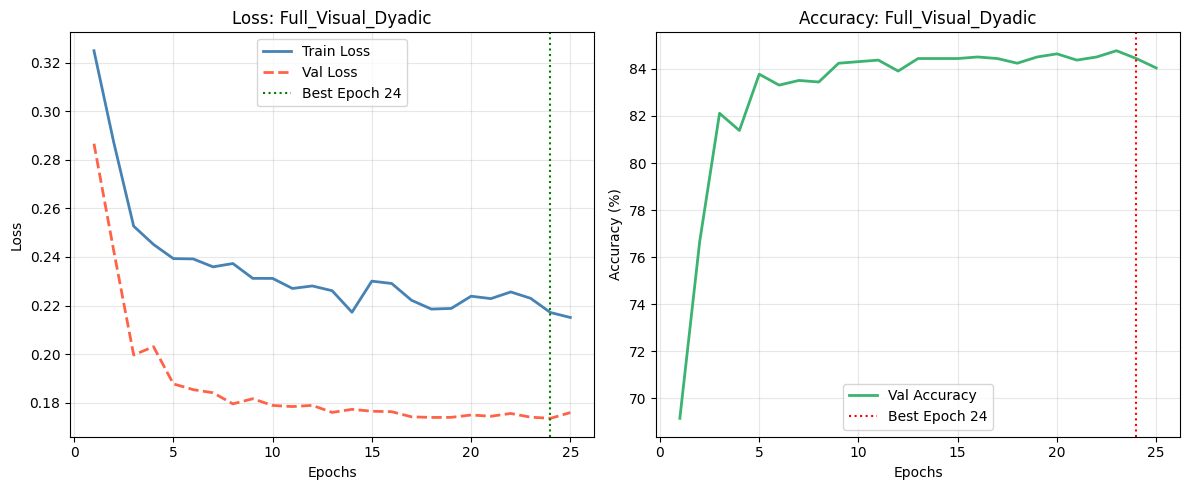

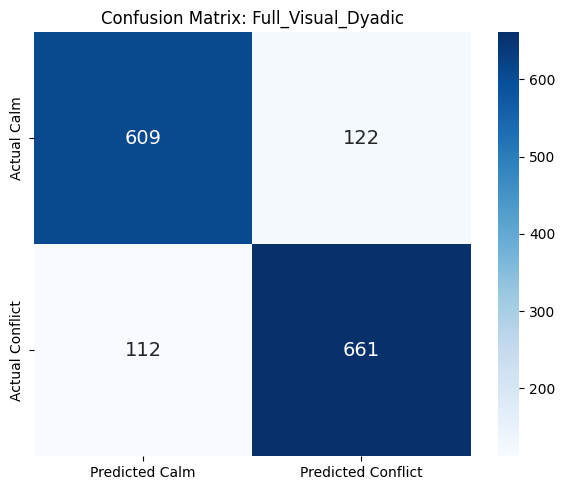

Plots saved to out/plots_visual_ablation/
Saved Full_Visual_Dyadic weights to out/models/feature_ablation_v1/Full_Visual_Dyadic_best_weights.pt

EXPERIMENT: FAU_Only
Active self   streams: ['fau']
Active partner streams: ['fau']

Epoch [01/25] | Train Loss: 0.3288 | Val Loss: 0.2750 | Val Acc: 74.87% | LR: 1.00e-04
Epoch [05/25] | Train Loss: 0.2493 | Val Loss: 0.2090 | Val Acc: 80.25% | LR: 9.33e-05
Epoch [10/25] | Train Loss: 0.2318 | Val Loss: 0.1815 | Val Acc: 83.64% | LR: 6.91e-05
Epoch [15/25] | Train Loss: 0.2292 | Val Loss: 0.1829 | Val Acc: 84.04% | LR: 3.71e-05

  Early stopping at epoch 18.

Restoring best weights from Epoch 12 (Val Loss: 0.1796)

FINAL RESULTS: FAU_Only
Accuracy : 84.38%
F1 (macro): 0.8432
--------------------------------------------------
              precision    recall  f1-score   support

    Calm (0)       0.86      0.81      0.83       731
Conflict (1)       0.83      0.88      0.85       773

    accuracy                           0.84      1504
   

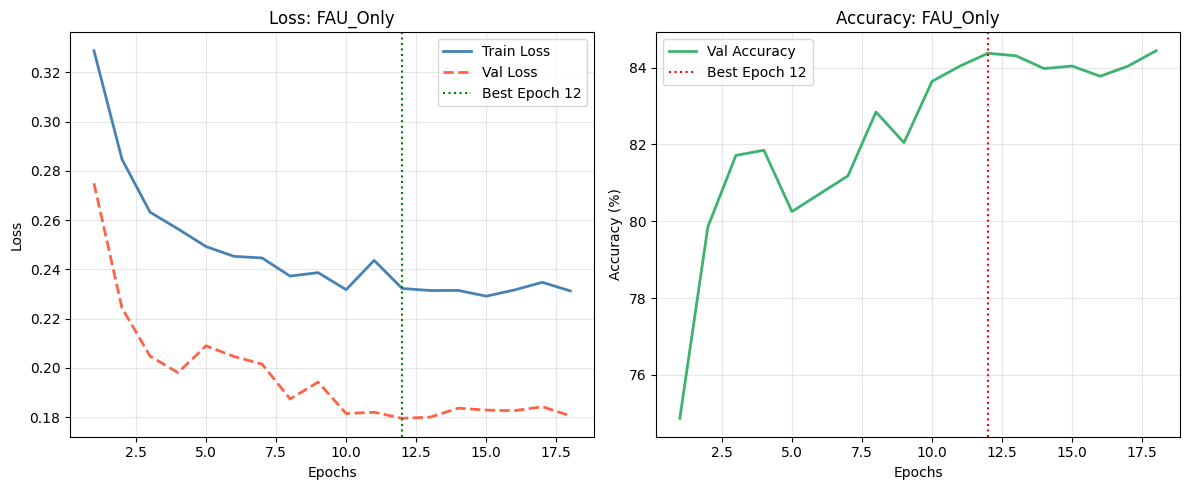

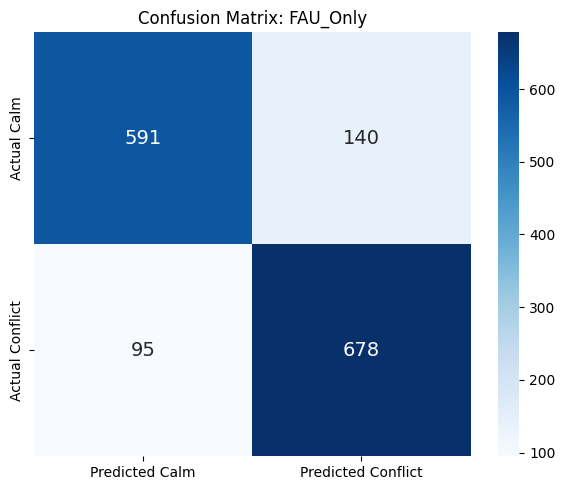

Plots saved to out/plots_visual_ablation/
Saved FAU_Only weights to out/models/feature_ablation_v1/FAU_Only_best_weights.pt

EXPERIMENT: Head_Only
Active self   streams: ['head']
Active partner streams: ['head']

Epoch [01/25] | Train Loss: 0.3296 | Val Loss: 0.3147 | Val Acc: 65.76% | LR: 1.00e-04
Epoch [05/25] | Train Loss: 0.2927 | Val Loss: 0.2821 | Val Acc: 71.28% | LR: 9.33e-05
Epoch [10/25] | Train Loss: 0.2832 | Val Loss: 0.2845 | Val Acc: 72.21% | LR: 6.91e-05

  Early stopping at epoch 14.

Restoring best weights from Epoch 8 (Val Loss: 0.2771)

FINAL RESULTS: Head_Only
Accuracy : 72.67%
F1 (macro): 0.7265
--------------------------------------------------
              precision    recall  f1-score   support

    Calm (0)       0.72      0.72      0.72       731
Conflict (1)       0.73      0.74      0.74       773

    accuracy                           0.73      1504
   macro avg       0.73      0.73      0.73      1504
weighted avg       0.73      0.73      0.73      1504

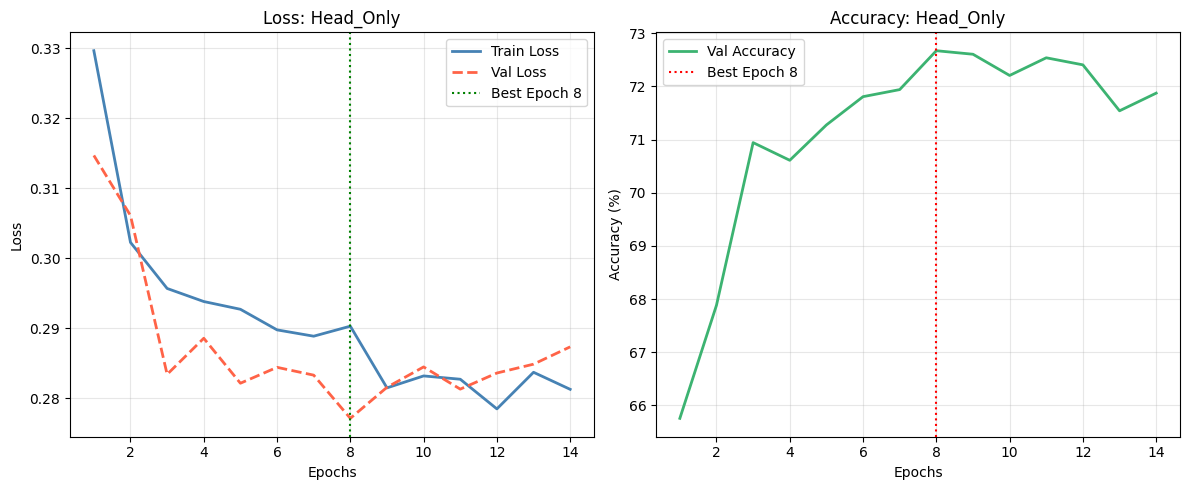

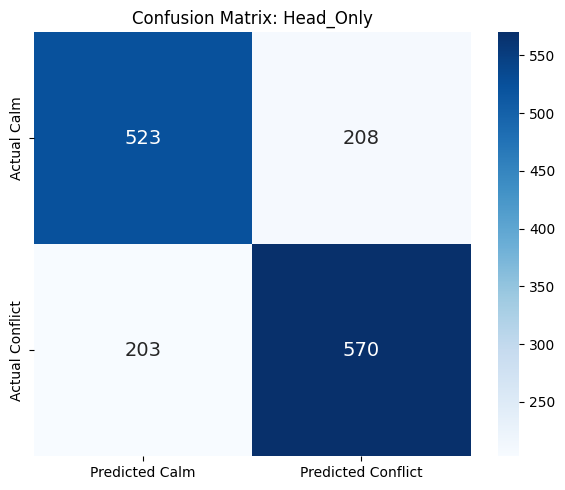

Plots saved to out/plots_visual_ablation/
Saved Head_Only weights to out/models/feature_ablation_v1/Head_Only_best_weights.pt

EXPERIMENT: Gaze_Only
Active self   streams: ['gaze']
Active partner streams: ['gaze']

Epoch [01/25] | Train Loss: 0.3448 | Val Loss: 0.3570 | Val Acc: 54.06% | LR: 1.00e-04
Epoch [05/25] | Train Loss: 0.3271 | Val Loss: 0.3575 | Val Acc: 59.91% | LR: 9.33e-05
Epoch [10/25] | Train Loss: 0.3183 | Val Loss: 0.3087 | Val Acc: 67.55% | LR: 6.91e-05
Epoch [15/25] | Train Loss: 0.3149 | Val Loss: 0.3044 | Val Acc: 67.95% | LR: 3.71e-05
Epoch [20/25] | Train Loss: 0.3110 | Val Loss: 0.3043 | Val Acc: 68.42% | LR: 1.03e-05

  Early stopping at epoch 22.

Restoring best weights from Epoch 16 (Val Loss: 0.3025)

FINAL RESULTS: Gaze_Only
Accuracy : 68.48%
F1 (macro): 0.6843
--------------------------------------------------
              precision    recall  f1-score   support

    Calm (0)       0.65      0.75      0.70       731
Conflict (1)       0.72      0.62      

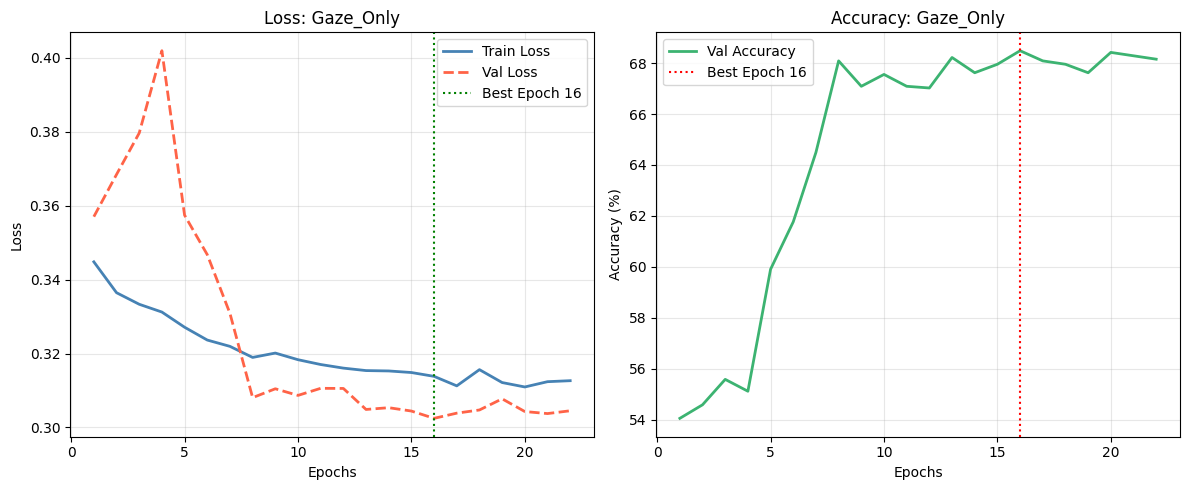

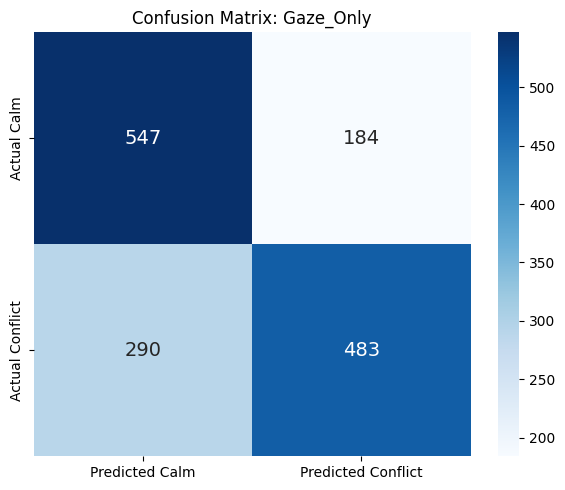

Plots saved to out/plots_visual_ablation/
Saved Gaze_Only weights to out/models/feature_ablation_v1/Gaze_Only_best_weights.pt

EXPERIMENT: Body_Only
Active self   streams: ['body']
Active partner streams: ['body']

Epoch [01/25] | Train Loss: 0.3157 | Val Loss: 0.2789 | Val Acc: 70.61% | LR: 1.00e-04
Epoch [05/25] | Train Loss: 0.2851 | Val Loss: 0.2601 | Val Acc: 73.40% | LR: 9.33e-05
Epoch [10/25] | Train Loss: 0.2822 | Val Loss: 0.2577 | Val Acc: 72.87% | LR: 6.91e-05
Epoch [15/25] | Train Loss: 0.2778 | Val Loss: 0.2584 | Val Acc: 73.01% | LR: 3.71e-05

  Early stopping at epoch 16.

Restoring best weights from Epoch 10 (Val Loss: 0.2577)

FINAL RESULTS: Body_Only
Accuracy : 72.87%
F1 (macro): 0.7269
--------------------------------------------------
              precision    recall  f1-score   support

    Calm (0)       0.75      0.67      0.70       731
Conflict (1)       0.71      0.79      0.75       773

    accuracy                           0.73      1504
   macro avg     

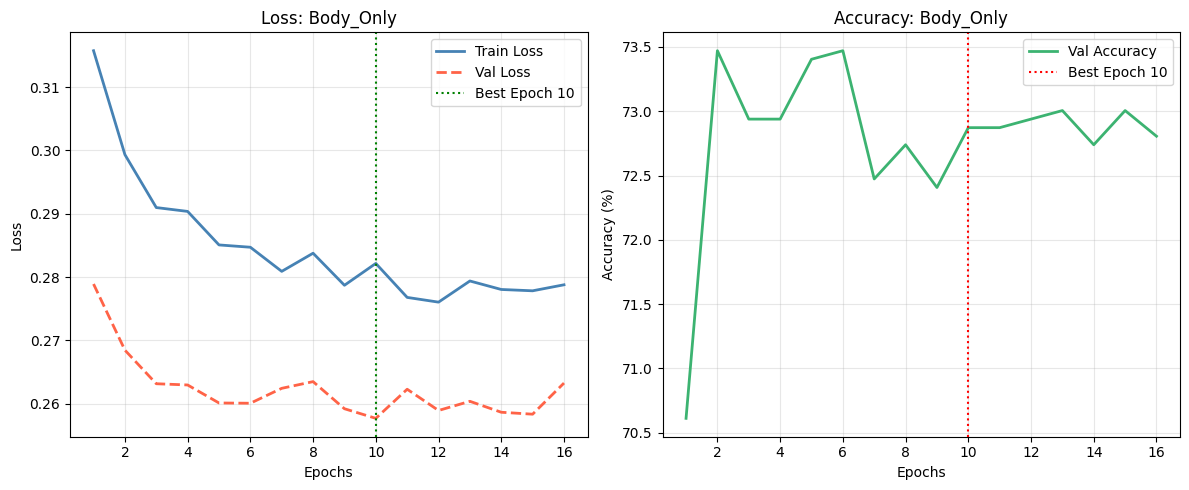

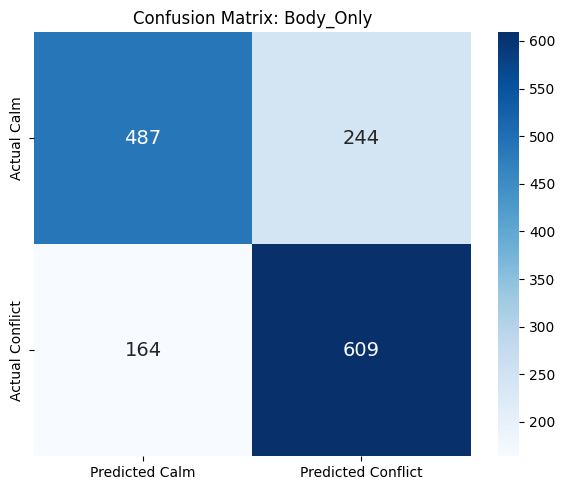

Plots saved to out/plots_visual_ablation/
Saved Body_Only weights to out/models/feature_ablation_v1/Body_Only_best_weights.pt

EXPERIMENT: FAU_Head
Active self   streams: ['fau', 'head']
Active partner streams: ['fau', 'head']

Epoch [01/25] | Train Loss: 0.3288 | Val Loss: 0.2987 | Val Acc: 67.75% | LR: 1.00e-04
Epoch [05/25] | Train Loss: 0.2510 | Val Loss: 0.2033 | Val Acc: 81.85% | LR: 9.33e-05
Epoch [10/25] | Train Loss: 0.2402 | Val Loss: 0.1922 | Val Acc: 83.24% | LR: 6.91e-05
Epoch [15/25] | Train Loss: 0.2327 | Val Loss: 0.1858 | Val Acc: 83.51% | LR: 3.71e-05
Epoch [20/25] | Train Loss: 0.2262 | Val Loss: 0.1832 | Val Acc: 83.71% | LR: 1.03e-05
Epoch [25/25] | Train Loss: 0.2286 | Val Loss: 0.1838 | Val Acc: 83.58% | LR: 0.00e+00

Restoring best weights from Epoch 20 (Val Loss: 0.1832)

FINAL RESULTS: FAU_Head
Accuracy : 83.71%
F1 (macro): 0.8371
--------------------------------------------------
              precision    recall  f1-score   support

    Calm (0)       0.82  

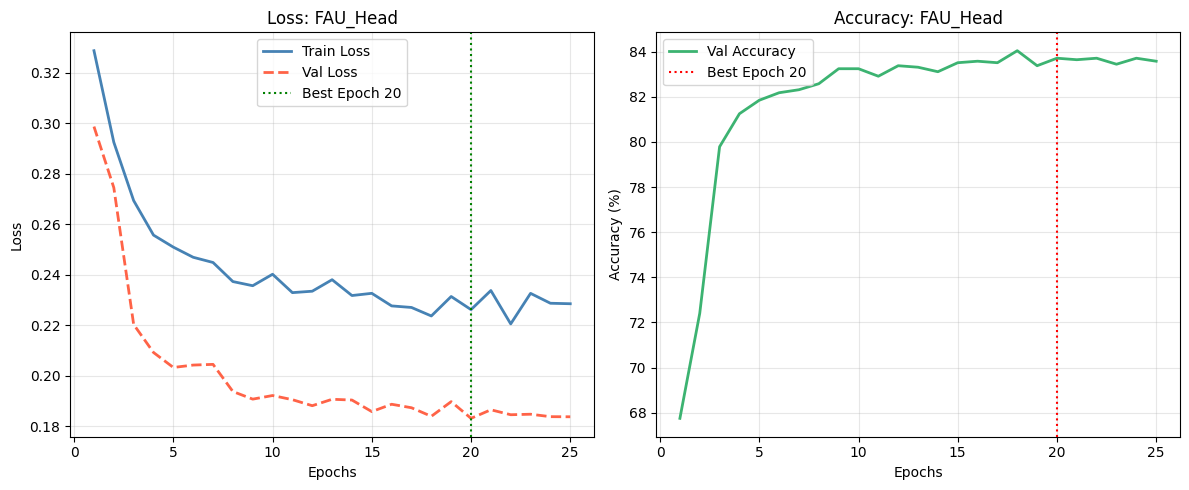

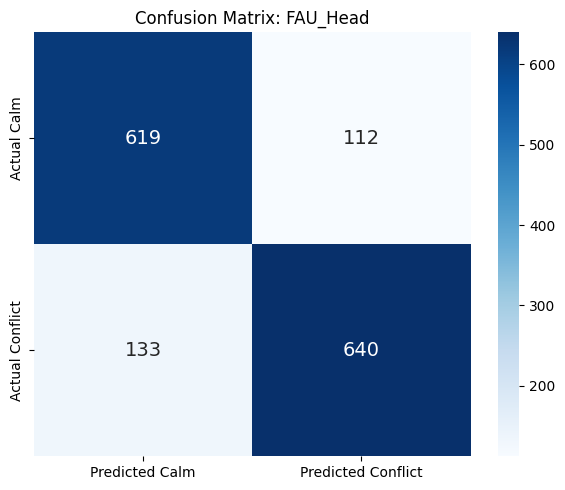

Plots saved to out/plots_visual_ablation/
Saved FAU_Head weights to out/models/feature_ablation_v1/FAU_Head_best_weights.pt

EXPERIMENT: FAU_Gaze
Active self   streams: ['fau', 'gaze']
Active partner streams: ['fau', 'gaze']

Epoch [01/25] | Train Loss: 0.3281 | Val Loss: 0.3167 | Val Acc: 64.16% | LR: 1.00e-04
Epoch [05/25] | Train Loss: 0.2538 | Val Loss: 0.2036 | Val Acc: 81.65% | LR: 9.33e-05
Epoch [10/25] | Train Loss: 0.2310 | Val Loss: 0.1847 | Val Acc: 82.25% | LR: 6.91e-05
Epoch [15/25] | Train Loss: 0.2303 | Val Loss: 0.1972 | Val Acc: 81.05% | LR: 3.71e-05

  Early stopping at epoch 18.

Restoring best weights from Epoch 12 (Val Loss: 0.1833)

FINAL RESULTS: FAU_Gaze
Accuracy : 82.18%
F1 (macro): 0.8207
--------------------------------------------------
              precision    recall  f1-score   support

    Calm (0)       0.85      0.76      0.81       731
Conflict (1)       0.80      0.88      0.83       773

    accuracy                           0.82      1504
   macr

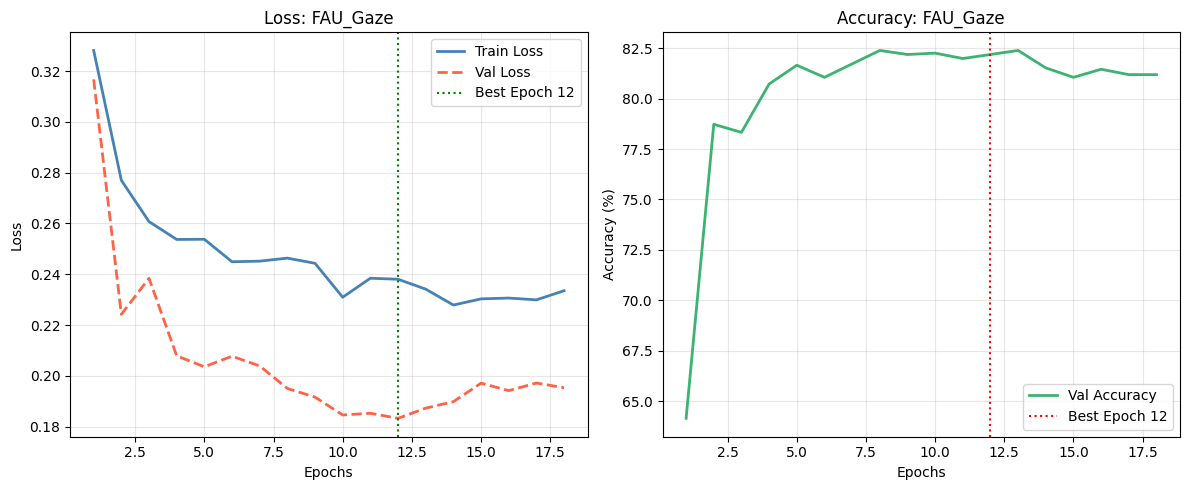

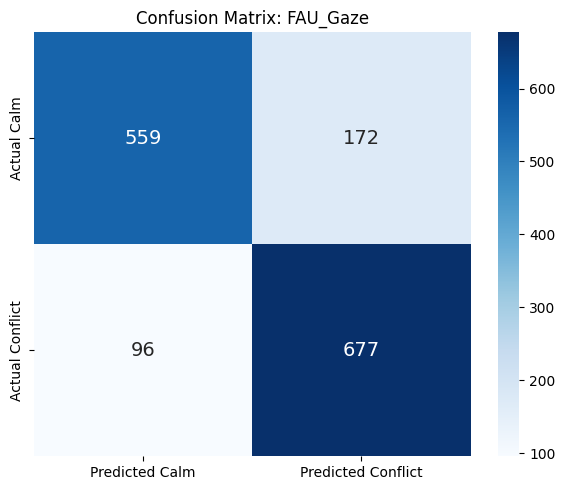

Plots saved to out/plots_visual_ablation/
Saved FAU_Gaze weights to out/models/feature_ablation_v1/FAU_Gaze_best_weights.pt

EXPERIMENT: FAU_Body
Active self   streams: ['body', 'fau']
Active partner streams: ['body', 'fau']

Epoch [01/25] | Train Loss: 0.3182 | Val Loss: 0.3104 | Val Acc: 67.55% | LR: 1.00e-04
Epoch [05/25] | Train Loss: 0.2390 | Val Loss: 0.2707 | Val Acc: 77.66% | LR: 9.33e-05
Epoch [10/25] | Train Loss: 0.2316 | Val Loss: 0.2221 | Val Acc: 80.72% | LR: 6.91e-05
Epoch [15/25] | Train Loss: 0.2241 | Val Loss: 0.2074 | Val Acc: 82.25% | LR: 3.71e-05
Epoch [20/25] | Train Loss: 0.2209 | Val Loss: 0.2155 | Val Acc: 81.52% | LR: 1.03e-05

  Early stopping at epoch 22.

Restoring best weights from Epoch 16 (Val Loss: 0.2066)

FINAL RESULTS: FAU_Body
Accuracy : 82.31%
F1 (macro): 0.8213
--------------------------------------------------
              precision    recall  f1-score   support

    Calm (0)       0.75      0.95      0.84       731
Conflict (1)       0.94      

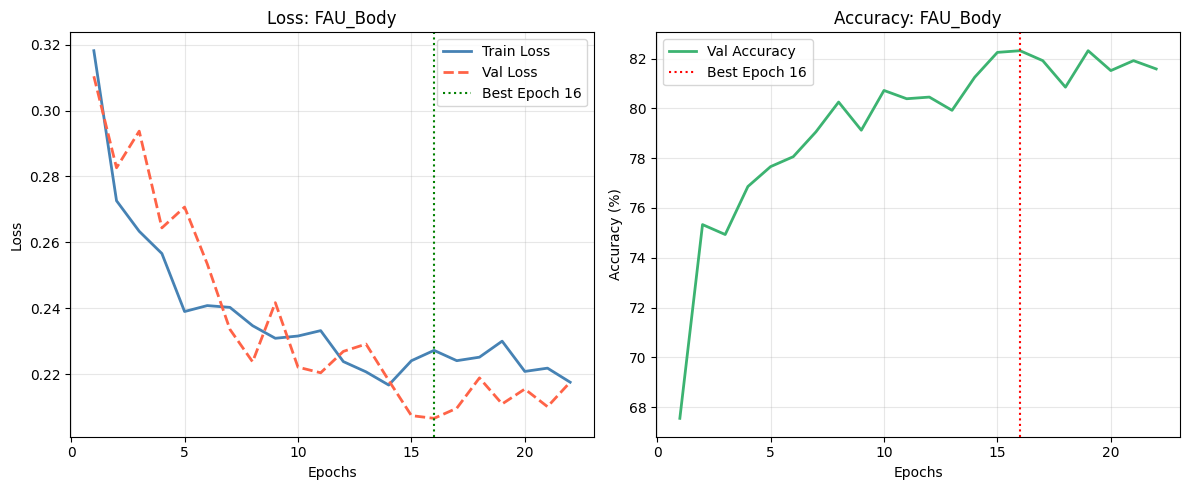

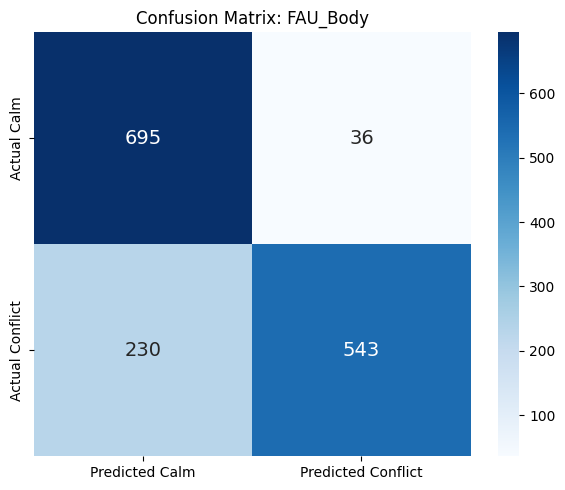

Plots saved to out/plots_visual_ablation/
Saved FAU_Body weights to out/models/feature_ablation_v1/FAU_Body_best_weights.pt

EXPERIMENT: NoBody_FaceOnly
Active self   streams: ['fau', 'gaze', 'head']
Active partner streams: ['fau', 'gaze', 'head']

Epoch [01/25] | Train Loss: 0.3294 | Val Loss: 0.3010 | Val Acc: 67.15% | LR: 1.00e-04
Epoch [05/25] | Train Loss: 0.2522 | Val Loss: 0.1934 | Val Acc: 81.65% | LR: 9.33e-05
Epoch [10/25] | Train Loss: 0.2355 | Val Loss: 0.1855 | Val Acc: 83.24% | LR: 6.91e-05
Epoch [15/25] | Train Loss: 0.2284 | Val Loss: 0.1843 | Val Acc: 83.51% | LR: 3.71e-05
Epoch [20/25] | Train Loss: 0.2300 | Val Loss: 0.1785 | Val Acc: 84.31% | LR: 1.03e-05
Epoch [25/25] | Train Loss: 0.2371 | Val Loss: 0.1782 | Val Acc: 84.31% | LR: 0.00e+00

Restoring best weights from Epoch 22 (Val Loss: 0.1779)

FINAL RESULTS: NoBody_FaceOnly
Accuracy : 84.44%
F1 (macro): 0.8441
--------------------------------------------------
              precision    recall  f1-score   suppor

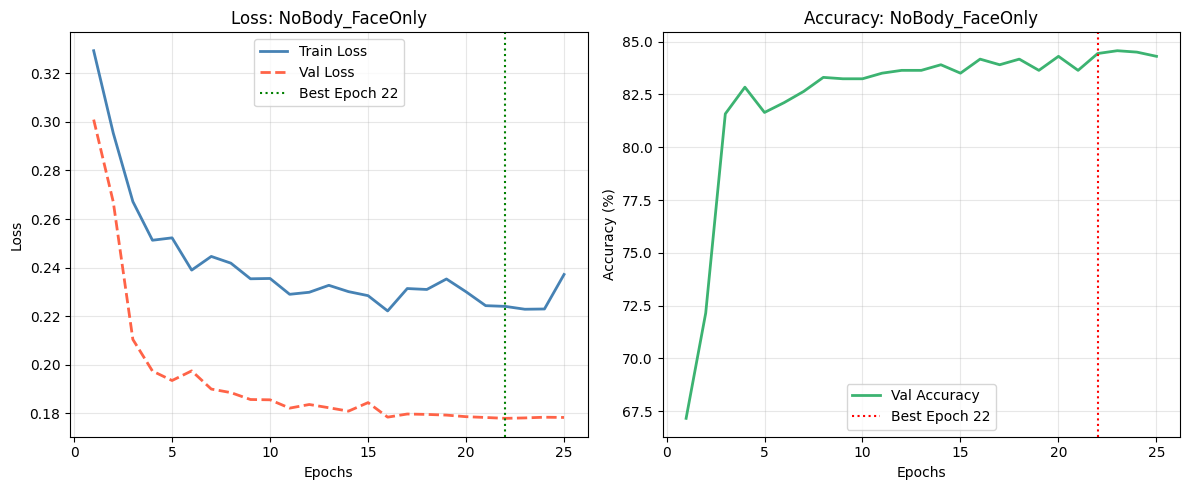

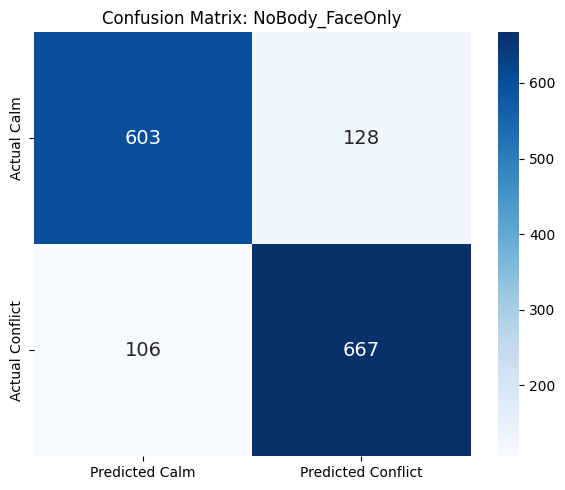

Plots saved to out/plots_visual_ablation/
Saved NoBody_FaceOnly weights to out/models/feature_ablation_v1/NoBody_FaceOnly_best_weights.pt

EXPERIMENT: Body_Self_FAU_Partner
Active self   streams: ['body']
Active partner streams: ['fau']

Epoch [01/25] | Train Loss: 0.3186 | Val Loss: 0.2789 | Val Acc: 70.74% | LR: 1.00e-04
Epoch [05/25] | Train Loss: 0.2809 | Val Loss: 0.2635 | Val Acc: 72.41% | LR: 9.33e-05
Epoch [10/25] | Train Loss: 0.2770 | Val Loss: 0.2595 | Val Acc: 72.94% | LR: 6.91e-05
Epoch [15/25] | Train Loss: 0.2734 | Val Loss: 0.2607 | Val Acc: 73.80% | LR: 3.71e-05
Epoch [20/25] | Train Loss: 0.2775 | Val Loss: 0.2575 | Val Acc: 73.74% | LR: 1.03e-05

  Early stopping at epoch 22.

Restoring best weights from Epoch 16 (Val Loss: 0.2572)

FINAL RESULTS: Body_Self_FAU_Partner
Accuracy : 73.80%
F1 (macro): 0.7371
--------------------------------------------------
              precision    recall  f1-score   support

    Calm (0)       0.75      0.70      0.72       731
Conf

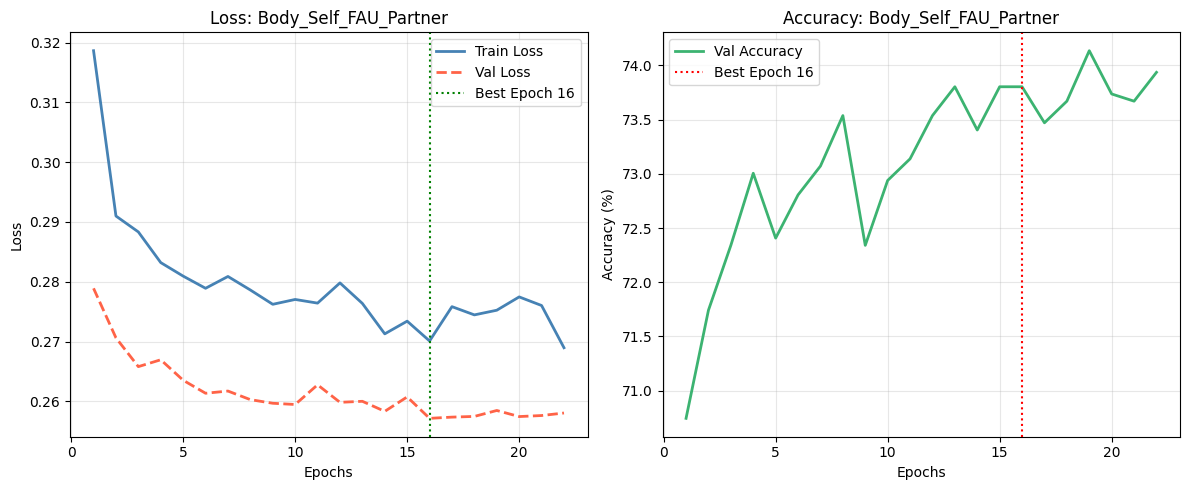

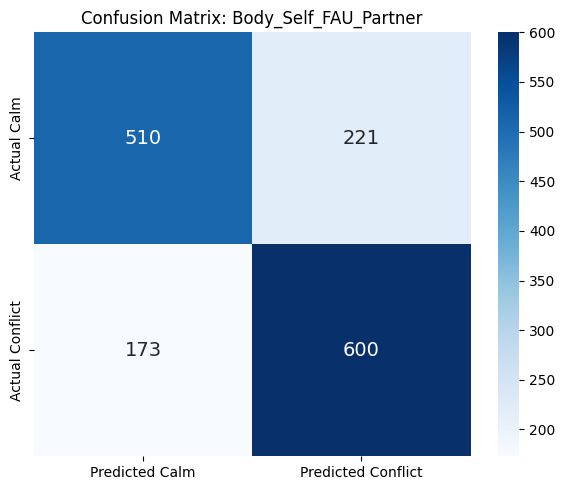

Plots saved to out/plots_visual_ablation/
Saved Body_Self_FAU_Partner weights to out/models/feature_ablation_v1/Body_Self_FAU_Partner_best_weights.pt

ABLATION SUMMARY — v3 Visual Feature Analysis
Experiment                   Self streams           Partner streams          Acc       F1
----------------------------------------------------------------------
Full_Visual_Dyadic           body+fau+gaze+head     body+fau+gaze+head    84.44%   0.8442
FAU_Only                     fau                    fau                   84.38%   0.8432
Head_Only                    head                   head                  72.67%   0.7265
Gaze_Only                    gaze                   gaze                  68.48%   0.6843
Body_Only                    body                   body                  72.87%   0.7269
FAU_Head                     fau+head               fau+head              83.71%   0.8371
FAU_Gaze                     fau+gaze               fau+gaze              82.18%   0.8207
FAU_Body    

In [ ]:
# TRAINING LOOP

def train_and_evaluate(
    model,
    train_loader,
    test_loader,
    device,
    train_df,
    active_vs: set,
    active_vp: set,
    epochs:          int   = 25,
    lr:              float = 1e-4,
    mixup_alpha:     float = 0.2,
    label_smooth:    float = 0.05,
    experiment_name: str   = "VisualDyadic",
    plot_dir:        str   = "out/plots_visual_ablation",
):
    print(f"\n{'='*60}")
    print(f"EXPERIMENT: {experiment_name}")
    print(f"Active self   streams: {sorted(active_vs) if active_vs else '(none)'}")
    print(f"Active partner streams: {sorted(active_vp) if active_vp else '(none)'}")
    print(f"{'='*60}\n")

    model = model.to(device)

    class_counts = train_df["label"].value_counts().sort_index().values
    weights      = torch.tensor(1.0 / class_counts.astype(float), dtype=torch.float32)
    weights      = (weights / weights.sum()).to(device)

    total_steps  = epochs * len(train_loader)
    warmup_steps = len(train_loader)
    optimizer    = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-3)
    scheduler    = get_cosine_schedule_with_warmup(optimizer, warmup_steps, total_steps)

    stream_keys   = ["vs_fau", "vs_head", "vs_gaze", "vs_body",
                     "vp_fau", "vp_head", "vp_gaze", "vp_body"]

    train_losses, val_losses, val_accuracies = [], [], []
    best_val_loss  = float("inf")
    best_model_wts = copy.deepcopy(model.state_dict())
    best_epoch     = 1
    patience       = 6
    patience_ctr   = 0

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for batch in train_loader:
            *stream_tensors, batch_y = batch
            stream_tensors = [t.to(device) for t in stream_tensors]
            batch_y        = batch_y.to(device)

            mixed, soft_y = mixup_batch(stream_tensors, batch_y, alpha=mixup_alpha)
            if label_smooth > 0:
                soft_y = (1 - label_smooth) * soft_y + label_smooth / soft_y.size(1)

            sub_streams = dict(zip(stream_keys, mixed))
            logits       = model(sub_streams, active_vs, active_vp)

            log_probs    = F.log_softmax(logits, dim=-1)
            loss         = -(soft_y * (log_probs * weights.unsqueeze(0))).sum(dim=-1).mean()

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            scheduler.step()
            running_loss += loss.item()

        epoch_train_loss = running_loss / len(train_loader)
        train_losses.append(epoch_train_loss)

        model.eval()
        running_val_loss = 0.0
        val_preds, val_targets = [], []

        with torch.no_grad():
            for batch in test_loader:
                *stream_tensors, batch_y = batch
                stream_tensors = [t.to(device) for t in stream_tensors]
                batch_y        = batch_y.to(device)

                sub_streams = dict(zip(stream_keys, stream_tensors))
                logits       = model(sub_streams, active_vs, active_vp)

                y_onehot  = torch.zeros_like(logits).scatter_(1, batch_y.unsqueeze(1), 1.0)
                log_probs = F.log_softmax(logits, dim=-1)
                val_loss  = -(y_onehot * (log_probs * weights.unsqueeze(0))).sum(dim=-1).mean()
                running_val_loss += val_loss.item()

                _, predicted = torch.max(logits, 1)
                val_preds.extend(predicted.cpu().numpy())
                val_targets.extend(batch_y.cpu().numpy())

        epoch_val_loss = running_val_loss / len(test_loader)
        epoch_val_acc  = accuracy_score(val_targets, val_preds)
        val_losses.append(epoch_val_loss)
        val_accuracies.append(epoch_val_acc)

        if (epoch + 1) % 5 == 0 or epoch == 0:
            current_lr = optimizer.param_groups[0]["lr"]
            print(f"Epoch [{epoch+1:02d}/{epochs}] | "
                  f"Train Loss: {epoch_train_loss:.4f} | "
                  f"Val Loss: {epoch_val_loss:.4f} | "
                  f"Val Acc: {epoch_val_acc*100:.2f}% | "
                  f"LR: {current_lr:.2e}")

        if epoch_val_loss < best_val_loss:
            best_val_loss  = epoch_val_loss
            best_model_wts = copy.deepcopy(model.state_dict())
            best_epoch     = epoch + 1
            patience_ctr   = 0
        else:
            patience_ctr += 1
            if patience_ctr >= patience:
                print(f"\n  Early stopping at epoch {epoch+1}.")
                break

    print(f"\nRestoring best weights from Epoch {best_epoch} (Val Loss: {best_val_loss:.4f})")
    model.load_state_dict(best_model_wts)

    model.eval()
    final_preds, final_targets = [], []
    with torch.no_grad():
        for batch in test_loader:
            *stream_tensors, batch_y = batch
            sub_streams = dict(zip(stream_keys, [t.to(device) for t in stream_tensors]))
            logits       = model(sub_streams, active_vs, active_vp)
            _, predicted = torch.max(logits, 1)
            final_preds.extend(predicted.cpu().numpy())
            final_targets.extend(batch_y.numpy())

    best_acc = accuracy_score(final_targets, final_preds)
    f1       = f1_score(final_targets, final_preds, average="macro")

    print("\n" + "="*50)
    print(f"FINAL RESULTS: {experiment_name}")
    print("="*50)
    print(f"Accuracy : {best_acc*100:.2f}%")
    print(f"F1 (macro): {f1:.4f}")
    print("-"*50)
    print(classification_report(final_targets, final_preds,
                                target_names=["Calm (0)", "Conflict (1)"]))

    # Print learned gates for active sub-streams
    gate_str = []
    for k in ["fau", "head", "gaze", "body"]:
        if k in active_vs:
            gate_str.append(f"VS_{k}: {torch.sigmoid(model.gate_vs[k]).item():.3f}")
        if k in active_vp:
            gate_str.append(f"VP_{k}: {torch.sigmoid(model.gate_vp[k]).item():.3f}")
    if gate_str:
        print("Learned gates — " + " | ".join(gate_str))

    # Plots
    os.makedirs(plot_dir, exist_ok=True)
    epochs_run = len(train_losses)

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(range(1, epochs_run + 1), train_losses,
             label="Train Loss", color="steelblue", linewidth=2)
    plt.plot(range(1, epochs_run + 1), val_losses,
             label="Val Loss", color="tomato", linewidth=2, linestyle="--")
    plt.axvline(x=best_epoch, color="green", linestyle=":", label=f"Best Epoch {best_epoch}")
    plt.title(f"Loss: {experiment_name}", fontsize=12)
    plt.xlabel("Epochs"); plt.ylabel("Loss")
    plt.legend(); plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(range(1, epochs_run + 1), [a * 100 for a in val_accuracies],
             label="Val Accuracy", color="mediumseagreen", linewidth=2)
    plt.axvline(x=best_epoch, color="red", linestyle=":", label=f"Best Epoch {best_epoch}")
    plt.title(f"Accuracy: {experiment_name}", fontsize=12)
    plt.xlabel("Epochs"); plt.ylabel("Accuracy (%)")
    plt.legend(); plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(plot_dir, f"{experiment_name}_curves.png"), dpi=200)
    try:
        plt.show(block=False); plt.pause(2)
    except Exception:
        pass
    plt.close()

    cm = confusion_matrix(final_targets, final_preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Predicted Calm", "Predicted Conflict"],
                yticklabels=["Actual Calm",    "Actual Conflict"],
                annot_kws={"size": 14})
    plt.title(f"Confusion Matrix: {experiment_name}", fontsize=12)
    plt.tight_layout()
    plt.savefig(os.path.join(plot_dir, f"{experiment_name}_cm.png"), dpi=200)
    try:
        plt.show(block=False); plt.pause(2)
    except Exception:
        pass
    plt.close()

    print(f"Plots saved to {plot_dir}/")
    return best_acc, f1

if __name__ == "__main__":
    set_seed(42)

    # ---- Load feature boundaries ----
    feature_slices = load_feature_dims("embeddings/video_feature_dims.json")
    print("Feature slices loaded:")
    for k, (s, e) in feature_slices.items():
        print(f"  {k:4s}: cols [{s}:{e}]  dim={e-s}")

    feature_dims = {k: (e - s) for k, (s, e) in feature_slices.items()}

    # ---- Load data ----
    df = pd.read_csv("out/master_dataset_dyadic.csv")
    self_video_dict    = torch.load("embeddings/video_self_sequences_v1.pt",
                                    map_location="cpu", weights_only=False)
    partner_video_dict = torch.load("embeddings/video_partner_sequences_v1.pt",
                                    map_location="cpu", weights_only=False)

    # ---- Group-based split (must match v1/v2 seed for fair comparison) ----
    train_df, test_df = group_split(df, test_size=0.20, seed=42)
    print(f"\nTrain: {len(train_df)} utterances | Test: {len(test_df)} utterances")

    # ---- Datasets ----
    train_dataset = VisualAblationDataset(
        train_df, self_video_dict, partner_video_dict, feature_slices
    )
    test_dataset = VisualAblationDataset(
        test_df, self_video_dict, partner_video_dict, feature_slices
    )

    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True,
                              num_workers=8, pin_memory=True)
    test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False,
                              num_workers=8, pin_memory=True)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Device: {device}")

    ALL  = {"fau", "head", "gaze", "body"}
    FACE = {"fau", "head", "gaze"}   # everything except body

    # =================================================================
    # 10 ABLATION EXPERIMENTS
    # Format: (name, active_self_streams, active_partner_streams)
    #
    # Interpretation guide:
    #  - Exp 1 is the sanity check — should match v2 SelfVideo_PartnerVideo ~85%
    #  - Exps 2-5: single feature type both speakers — isolates each signal
    #  - Exps 6-8: pairwise combinations with FAU as anchor
    #  - Exp 9:  all face features (no body) — pure facial ablation
    #  - Exp 10: asymmetric dyadic — body self + fau partner
    #            (most theoretically motivated cross-speaker pairing)
    # =================================================================
    experiments = [
        # (name,                         active_vs,          active_vp)
        ("Full_Visual_Dyadic",           ALL,                ALL),
        ("FAU_Only",                     {"fau"},            {"fau"}),
        ("Head_Only",                    {"head"},           {"head"}),
        ("Gaze_Only",                    {"gaze"},           {"gaze"}),
        ("Body_Only",                    {"body"},           {"body"}),
        ("FAU_Head",                     {"fau","head"},     {"fau","head"}),
        ("FAU_Gaze",                     {"fau","gaze"},     {"fau","gaze"}),
        ("FAU_Body",                     {"fau","body"},     {"fau","body"}),
        ("NoBody_FaceOnly",              FACE,               FACE),
        ("Body_Self_FAU_Partner",        {"body"},           {"fau"}),
    ]

    save_dir = "out/models/feature_ablation_v1"
    os.makedirs(save_dir, exist_ok=True)

    results = {}
    for exp_name, act_vs, act_vp in experiments:
        model = VisualDyadicMulT(
            feature_dims=feature_dims,
            shared_dim=64,
            num_heads=4,
        ).to(device)

        acc, f1 = train_and_evaluate(
            model, train_loader, test_loader, device, train_df,
            active_vs=act_vs, active_vp=act_vp,
            epochs=25, lr=1e-4,
            mixup_alpha=0.2, label_smooth=0.05,
            experiment_name=exp_name,
        )
        results[exp_name] = {
            "accuracy":  acc,
            "f1_macro":  f1,
            "active_vs": sorted(act_vs),
            "active_vp": sorted(act_vp),
        }

        save_path = os.path.join(save_dir, f"{exp_name}_best_weights.pt")
        torch.save(model.state_dict(), save_path)
        print(f"Saved {exp_name} weights to {save_path}")

    print("\n" + "="*70)
    print("ABLATION SUMMARY — v3 Visual Feature Analysis")
    print("="*70)
    print(f"{'Experiment':<28} {'Self streams':<22} {'Partner streams':<20} {'Acc':>7} {'F1':>8}")
    print("-"*70)
    for name, r in results.items():
        vs_str = "+".join(r["active_vs"])
        vp_str = "+".join(r["active_vp"])
        print(f"{name:<28} {vs_str:<22} {vp_str:<20} "
              f"{r['accuracy']*100:>6.2f}% {r['f1_macro']:>8.4f}")
    
    print("\n(Reference: v2 SelfVideo_PartnerVideo = 85.37% / F1 0.8536)")

# Optimized Audiovisual Fusion

## Imports & Random Seed

In [ ]:
import os
import math
import copy
import json
import random
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import GroupShuffleSplit

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def group_split(df: pd.DataFrame, test_size: float = 0.20, seed: int = 42):
    gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=seed)
    groups = df["file_id"].values
    train_idx, test_idx = next(gss.split(df, groups=groups))
    return df.iloc[train_idx].reset_index(drop=True), df.iloc[test_idx].reset_index(drop=True)

## Dataset & Mixup

In [ ]:
class DyadicAudioVisualDataset(Dataset):
    """
    Loads Audio, Self-Video, and Partner-Video.
    Slicing to isolate FAU happens in the training loop.
    """
    def __init__(self, df, audio_dict, self_video_dict, partner_video_dict):
        self.samples = []
        missing = 0
        for _, row in df.iterrows():
            s_id = row["sample_id"]
            if s_id in audio_dict and s_id in self_video_dict:
                # Handle missing partner videos (the 57 samples) by falling back to zeros
                vp = partner_video_dict.get(s_id, torch.zeros_like(self_video_dict[s_id]))
                self.samples.append({
                    "label": int(row["label"]),
                    "audio": audio_dict[s_id],
                    "video_self": self_video_dict[s_id],
                    "video_partner": vp,
                })
            else:
                missing += 1
        if missing > 0:
            print(f"  [Dataset] Skipped {missing} samples missing from dictionaries.")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        item = self.samples[idx]
        return (
            item["audio"].clone().float(),
            item["video_self"].clone().float(),
            item["video_partner"].clone().float(),
            torch.tensor(item["label"], dtype=torch.long),
        )

def mixup_3stream(x_A, x_VS, x_VP, y, alpha: float = 0.2):
    batch_size = y.size(0)
    num_classes = 2

    if alpha <= 0:
        y_soft = torch.zeros(batch_size, num_classes, device=y.device).scatter_(1, y.unsqueeze(1), 1.0)
        return x_A, x_VS, x_VP, y_soft

    lam = np.random.beta(alpha, alpha)
    lam = max(lam, 1 - lam)
    idx = torch.randperm(batch_size, device=x_A.device)

    x_A  = lam * x_A  + (1 - lam) * x_A[idx]
    x_VS = lam * x_VS + (1 - lam) * x_VS[idx]
    x_VP = lam * x_VP + (1 - lam) * x_VP[idx]

    y_a = torch.zeros(batch_size, num_classes, device=y.device).scatter_(1, y.unsqueeze(1), 1.0)
    y_b = torch.zeros(batch_size, num_classes, device=y.device).scatter_(1, y[idx].unsqueeze(1), 1.0)
    y_soft = lam * y_a + (1 - lam) * y_b
    
    return x_A, x_VS, x_VP, y_soft

## Model -- Audio + Speaker FAU + Partner FAU 

In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, dropout: float = 0.1, max_len: int = 2000):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
        position = torch.arange(max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        pe = torch.zeros(max_len, 1, d_model)
        pe[:, 0, 0::2] = torch.sin(position * div_term)
        pe[:, 0, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe)

    def forward(self, x):
        x = x.transpose(0, 1)
        x = x + self.pe[: x.size(0)]
        return self.dropout(x.transpose(0, 1))

class AttentionPool(nn.Module):
    def __init__(self, dim: int):
        super().__init__()
        self.score = nn.Linear(dim, 1)

    def forward(self, x):
        w = torch.softmax(self.score(x), dim=1)
        return (x * w).sum(dim=1)

class CrossModalAttentionBlock(nn.Module):
    def __init__(self, embed_dim: int, num_heads: int, dropout: float = 0.2):
        super().__init__()
        self.cross_attn = nn.MultiheadAttention(
            embed_dim=embed_dim, num_heads=num_heads,
            dropout=dropout, batch_first=True
        )
        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.ffn = nn.Sequential(
            nn.Linear(embed_dim, embed_dim * 2), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(embed_dim * 2, embed_dim),
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, query_seq, key_value_seq):
        attn_out, _ = self.cross_attn(query=query_seq, key=key_value_seq, value=key_value_seq)
        x = self.norm1(query_seq + self.dropout(attn_out))
        x = self.norm2(x + self.dropout(self.ffn(x)))
        return x

def get_cosine_schedule_with_warmup(optimizer, num_warmup_steps, num_training_steps):
    def lr_lambda(step):
        if step < num_warmup_steps:
            return float(step) / float(max(1, num_warmup_steps))
        progress = float(step - num_warmup_steps) / float(max(1, num_training_steps - num_warmup_steps))
        return max(0.0, 0.5 * (1.0 + math.cos(math.pi * progress)))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


In [ ]:
"""
Tests the fusion of Acoustic Prosody (Audio) + Speaker Facial Action Units (VS_FAU) 
+ Partner Facial Action Units (VP_FAU) to capture the purest dyadic conflict signal.
"""

class Audio_DyadicFAU_MulT(nn.Module):
    """
    Audio + Speaker FAU + Partner FAU
    Intra-speaker: Audio <-> Speaker FAU
    Cross-speaker: Speaker FAU <-> Partner FAU
    """
    def __init__(self, audio_dim=768, fau_dim=24, shared_dim=64, num_heads=4):
        super().__init__()
        self.shared_dim = shared_dim
        
        # Projections
        self.proj_audio  = nn.Conv1d(audio_dim, shared_dim, kernel_size=1)
        self.proj_vs_fau = nn.Conv1d(fau_dim, shared_dim, kernel_size=1)
        self.proj_vp_fau = nn.Conv1d(fau_dim, shared_dim, kernel_size=1)
        
        self.pos_encoder = PositionalEncoding(d_model=shared_dim, dropout=0.2)
        
        # Intra-Speaker Blocks
        self.trans_A_vsFAU = CrossModalAttentionBlock(shared_dim, num_heads)
        self.trans_vsFAU_A = CrossModalAttentionBlock(shared_dim, num_heads)
        
        # Cross-Speaker Blocks (Dyadic Extension)
        self.trans_vsFAU_vpFAU = CrossModalAttentionBlock(shared_dim, num_heads)
        self.trans_vpFAU_vsFAU = CrossModalAttentionBlock(shared_dim, num_heads)
        
        # Pools & Gates
        self.pool_A      = AttentionPool(shared_dim)
        self.pool_vs_FAU = AttentionPool(shared_dim)
        self.pool_vp_FAU = AttentionPool(shared_dim)
        
        self.gate_A      = nn.Parameter(torch.ones(1))
        self.gate_vs_FAU = nn.Parameter(torch.ones(1))
        self.gate_vp_FAU = nn.Parameter(torch.ones(1))
        
        # Classifier (3 streams * 64 = 192 inputs)
        self.classifier = nn.Sequential(
            nn.Linear(shared_dim * 3, 128),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.Dropout(0.4),
            nn.Linear(128, 64),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(64, 2)
        )

    def forward(self, x_audio, x_vs_fau, x_vp_fau):
        # Encode
        proj_A   = self.pos_encoder(self.proj_audio(x_audio.transpose(1, 2)).transpose(1, 2))
        proj_vsF = self.pos_encoder(self.proj_vs_fau(x_vs_fau.transpose(1, 2)).transpose(1, 2))
        proj_vpF = self.pos_encoder(self.proj_vp_fau(x_vp_fau.transpose(1, 2)).transpose(1, 2))
        
        # Attention Routing
        out_A   = self.trans_A_vsFAU(proj_A, proj_vsF)
        
        out_vsF = self.trans_vsFAU_A(proj_vsF, proj_A)
        out_vsF = self.trans_vsFAU_vpFAU(out_vsF, proj_vpF) # Speaker attends to Partner reaction
        
        out_vpF = self.trans_vpFAU_vsFAU(proj_vpF, proj_vsF) # Partner reaction attends to Speaker
        
        # Pool
        p_A   = self.pool_A(out_A)
        p_vsF = self.pool_vs_FAU(out_vsF)
        p_vpF = self.pool_vp_FAU(out_vpF)
        
        # Gate & Concat
        fused = torch.cat([
            torch.sigmoid(self.gate_A) * p_A, 
            torch.sigmoid(self.gate_vs_FAU) * p_vsF,
            torch.sigmoid(self.gate_vp_FAU) * p_vpF
        ], dim=-1)
        
        return self.classifier(fused)

In [ ]:
# TRAINING LOOP

def train_and_evaluate(
    model, train_loader, test_loader, device, train_df, 
    fau_slice, epochs=25, lr=1e-4, mixup_alpha=0.2, label_smooth=0.05
):
    experiment_name = "Audio_DyadicFAU"
    print(f"\n{'='*55}\nSTARTING EXPERIMENT: {experiment_name}\n{'='*55}\n")

    model = model.to(device)

    class_counts = train_df["label"].value_counts().sort_index().values
    weights = torch.tensor(1.0 / class_counts.astype(float), dtype=torch.float32)
    weights = (weights / weights.sum()).to(device)

    total_steps  = epochs * len(train_loader)
    warmup_steps = len(train_loader)
    optimizer    = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-3)
    scheduler    = get_cosine_schedule_with_warmup(optimizer, warmup_steps, total_steps)

    train_losses, val_losses, val_accuracies = [], [], []
    best_val_loss  = float("inf")
    best_model_wts = copy.deepcopy(model.state_dict())
    best_epoch     = 1
    patience       = 10
    patience_ctr   = 0

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for batch_A, batch_VS, batch_VP, batch_y in train_loader:
            batch_A  = batch_A.to(device)
            batch_VS = batch_VS.to(device)
            batch_VP = batch_VP.to(device)
            batch_y  = batch_y.to(device)
            
            # SLICE THE VISUAL TENSORS (ONLY FAU)
            batch_vs_FAU = batch_VS[:, :, fau_slice[0]:fau_slice[1]]
            batch_vp_FAU = batch_VP[:, :, fau_slice[0]:fau_slice[1]]

            # MixUp
            batch_A, batch_vs_FAU, batch_vp_FAU, soft_y = mixup_3stream(
                batch_A, batch_vs_FAU, batch_vp_FAU, batch_y, alpha=mixup_alpha
            )

            # Label smoothing
            if label_smooth > 0:
                soft_y = (1 - label_smooth) * soft_y + label_smooth / soft_y.size(1)

            logits = model(batch_A, batch_vs_FAU, batch_vp_FAU)

            log_probs = F.log_softmax(logits, dim=-1)
            weighted_log = log_probs * weights.unsqueeze(0)
            loss = -(soft_y * weighted_log).sum(dim=-1).mean()

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            scheduler.step()
            running_loss += loss.item()

        epoch_train_loss = running_loss / len(train_loader)
        train_losses.append(epoch_train_loss)

        # ---- Validation ----
        model.eval()
        running_val_loss = 0.0
        val_preds, val_targets = [], []

        with torch.no_grad():
            for batch_A, batch_VS, batch_VP, batch_y in test_loader:
                batch_A  = batch_A.to(device)
                batch_VS = batch_VS.to(device)
                batch_VP = batch_VP.to(device)
                batch_y  = batch_y.to(device)
                
                batch_vs_FAU = batch_VS[:, :, fau_slice[0]:fau_slice[1]]
                batch_vp_FAU = batch_VP[:, :, fau_slice[0]:fau_slice[1]]

                logits = model(batch_A, batch_vs_FAU, batch_vp_FAU)

                y_onehot = torch.zeros_like(logits).scatter_(1, batch_y.unsqueeze(1), 1.0)
                log_probs = F.log_softmax(logits, dim=-1)
                val_loss  = -(y_onehot * (log_probs * weights.unsqueeze(0))).sum(dim=-1).mean()
                running_val_loss += val_loss.item()

                _, predicted = torch.max(logits, 1)
                val_preds.extend(predicted.cpu().numpy())
                val_targets.extend(batch_y.cpu().numpy())

        epoch_val_loss = running_val_loss / len(test_loader)
        epoch_val_acc  = accuracy_score(val_targets, val_preds)
        val_losses.append(epoch_val_loss)
        val_accuracies.append(epoch_val_acc)

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch [{epoch+1:02d}/{epochs}] | Train Loss: {epoch_train_loss:.4f} | "
                  f"Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc*100:.2f}% | "
                  f"LR: {optimizer.param_groups[0]['lr']:.2e}")

        if epoch_val_loss < best_val_loss:
            best_val_loss  = epoch_val_loss
            best_model_wts = copy.deepcopy(model.state_dict())
            best_epoch     = epoch + 1
            patience_ctr   = 0
        else:
            patience_ctr += 1
            if patience_ctr >= patience:
                print(f"\n  Early stopping at epoch {epoch+1} (no improvement for {patience} epochs).")
                break

    print(f"\nRestoring best weights from Epoch {best_epoch} (Val Loss: {best_val_loss:.4f})")
    model.load_state_dict(best_model_wts)

    # ---- Final Evaluation ----
    model.eval()
    final_preds, final_targets = [], []
    with torch.no_grad():
        for batch_A, batch_VS, batch_VP, batch_y in test_loader:
            batch_vs_FAU = batch_VS[:, :, fau_slice[0]:fau_slice[1]].to(device)
            batch_vp_FAU = batch_VP[:, :, fau_slice[0]:fau_slice[1]].to(device)
            
            logits = model(batch_A.to(device), batch_vs_FAU, batch_vp_FAU)
            
            _, predicted = torch.max(logits, 1)
            final_preds.extend(predicted.cpu().numpy())
            final_targets.extend(batch_y.numpy())

    best_acc = accuracy_score(final_targets, final_preds)
    f1       = f1_score(final_targets, final_preds, average="macro")

    print("\n" + "="*50)
    print(f"FINAL RESULTS: {experiment_name}")
    print("="*50)
    print(f"Accuracy : {best_acc*100:.2f}%")
    print(f"F1 (macro): {f1:.4f}")
    print("-"*50)
    print(classification_report(final_targets, final_preds, target_names=["Calm (0)", "Conflict (1)"]))

    gA  = torch.sigmoid(model.gate_A).item()
    gVS = torch.sigmoid(model.gate_vs_FAU).item()
    gVP = torch.sigmoid(model.gate_vp_FAU).item()
    print(f"Learned gates — Audio: {gA:.3f} | Speaker FAU: {gVS:.3f} | Partner FAU: {gVP:.3f}")

    # ---- Plotting ----
    plot_dir = "out/plots_v3"
    os.makedirs(plot_dir, exist_ok=True)
    epochs_run = len(train_losses)

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(range(1, epochs_run + 1), train_losses, label="Train Loss", color="steelblue", linewidth=2)
    plt.plot(range(1, epochs_run + 1), val_losses, label="Val Loss", color="tomato", linewidth=2, linestyle="--")
    plt.axvline(x=best_epoch, color="green", linestyle=":", label=f"Best Epoch {best_epoch}")
    plt.title(f"Loss: {experiment_name}", fontsize=12)
    plt.legend(); plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(range(1, epochs_run + 1), [a * 100 for a in val_accuracies], label="Val Accuracy", color="mediumseagreen", linewidth=2)
    plt.axvline(x=best_epoch, color="red", linestyle=":", label=f"Best Epoch {best_epoch}")
    plt.title(f"Accuracy: {experiment_name}", fontsize=12)
    plt.legend(); plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(plot_dir, f"{experiment_name}_curves.png"), dpi=200)
    plt.close()

    cm = confusion_matrix(final_targets, final_preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Predicted Calm", "Predicted Conflict"],
                yticklabels=["Actual Calm", "Actual Conflict"], annot_kws={"size": 14})
    plt.title(f"Confusion Matrix: {experiment_name}", fontsize=12)
    plt.tight_layout()
    plt.savefig(os.path.join(plot_dir, f"{experiment_name}_cm.png"), dpi=200)
    plt.close()

    # Save model weights
    save_dir = "out/models/v3"
    os.makedirs(save_dir, exist_ok=True)
    save_path = os.path.join(save_dir, f"{experiment_name}_best_weights.pt")
    torch.save(model.state_dict(), save_path)
    print(f"\nModel weights saved to {save_path}")

if __name__ == "__main__":
    set_seed(42)

    # 1. Load JSON Metadata
    with open("embeddings/video_feature_dims.json", "r") as f:
        meta = json.load(f)
    fau_slice  = meta["fau_slice"]

    # 2. Load Embeddings and CSV
    df = pd.read_csv("out/master_dataset_dyadic.csv")
    
    print("Loading Audio & Video dictionaries...")
    audio_raw = torch.load("embeddings/audio_sequences_v2.pt", map_location="cpu", weights_only=False)
    audio_dict = audio_raw.get("audio_sequences", audio_raw) if isinstance(audio_raw, dict) else audio_raw
    self_video_dict = torch.load("embeddings/video_self_sequences_v1.pt", map_location="cpu", weights_only=False)
    partner_video_dict = torch.load("embeddings/video_partner_sequences_v1.pt", map_location="cpu", weights_only=False)

    # 3. Create Dataset & Splits
    train_df, test_df = group_split(df, test_size=0.20, seed=42)
    
    train_dataset = DyadicAudioVisualDataset(train_df, audio_dict, self_video_dict, partner_video_dict)
    test_dataset  = DyadicAudioVisualDataset(test_df, audio_dict, self_video_dict, partner_video_dict)

    AUDIO_DIM = next(iter(audio_dict.values())).shape[-1]
    FAU_DIM   = fau_slice[1] - fau_slice[0]

    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=8, pin_memory=True)
    test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=8, pin_memory=True)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # 4. Initialize Model and Train
    model = Audio_DyadicFAU_MulT(
        audio_dim=AUDIO_DIM, fau_dim=FAU_DIM, shared_dim=64, num_heads=4
    )
    
    train_and_evaluate(
        model, train_loader, test_loader, device, train_df, 
        fau_slice, epochs=25, lr=1e-4
    )

Loading Audio & Video dictionaries...
  [Dataset] Skipped 2 samples missing from dictionaries.

STARTING EXPERIMENT: Audio_DyadicFAU

Epoch [01/25] | Train Loss: 0.3417 | Val Loss: 0.2983 | Val Acc: 74.60% | LR: 1.00e-04
Epoch [05/25] | Train Loss: 0.2338 | Val Loss: 0.1741 | Val Acc: 84.77% | LR: 9.33e-05
Epoch [10/25] | Train Loss: 0.2215 | Val Loss: 0.1711 | Val Acc: 85.04% | LR: 6.91e-05
Epoch [15/25] | Train Loss: 0.2193 | Val Loss: 0.1675 | Val Acc: 85.70% | LR: 3.71e-05
Epoch [20/25] | Train Loss: 0.2127 | Val Loss: 0.1675 | Val Acc: 85.97% | LR: 1.03e-05
Epoch [25/25] | Train Loss: 0.2053 | Val Loss: 0.1666 | Val Acc: 86.37% | LR: 0.00e+00

Restoring best weights from Epoch 22 (Val Loss: 0.1630)

FINAL RESULTS: Audio_DyadicFAU
Accuracy : 86.30%
F1 (macro): 0.8630
--------------------------------------------------
              precision    recall  f1-score   support

    Calm (0)       0.83      0.90      0.87       731
Conflict (1)       0.90      0.83      0.86       773

   

## Model -- Audio + Speaker FAU 

In [ ]:
# 2-STREAM ARCHITECTURE

class Audio_FAU_MulT(nn.Module):
    def __init__(self, audio_dim=768, fau_dim=24, shared_dim=64, num_heads=4):
        super().__init__()
        self.shared_dim = shared_dim
        
        # Projections
        self.proj_audio = nn.Conv1d(audio_dim, shared_dim, kernel_size=1)
        self.proj_fau   = nn.Conv1d(fau_dim, shared_dim, kernel_size=1)
        
        self.pos_encoder = PositionalEncoding(d_model=shared_dim, dropout=0.2)
        
        # Cross Attention Blocks
        self.trans_A_FAU = CrossModalAttentionBlock(shared_dim, num_heads)
        self.trans_FAU_A = CrossModalAttentionBlock(shared_dim, num_heads)
        
        # Pools & Gates
        self.pool_A   = AttentionPool(shared_dim)
        self.pool_FAU = AttentionPool(shared_dim)
        
        self.gate_A   = nn.Parameter(torch.ones(1))
        self.gate_FAU = nn.Parameter(torch.ones(1))
        
        # Classifier (2 streams * 64 = 128 inputs)
        self.classifier = nn.Sequential(
            nn.Linear(shared_dim * 2, 64),
            nn.BatchNorm1d(64),
            nn.GELU(),
            nn.Dropout(0.4),
            nn.Linear(64, 32),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(32, 2)
        )

    def forward(self, x_audio, x_fau):
        # Encode
        proj_A   = self.pos_encoder(self.proj_audio(x_audio.transpose(1, 2)).transpose(1, 2))
        proj_FAU = self.pos_encoder(self.proj_fau(x_fau.transpose(1, 2)).transpose(1, 2))
        
        # Attention
        out_A   = self.trans_A_FAU(proj_A, proj_FAU)
        out_FAU = self.trans_FAU_A(proj_FAU, proj_A)
        
        # Pool
        p_A   = self.pool_A(out_A)
        p_FAU = self.pool_FAU(out_FAU)
        
        # Gate & Concat
        fused = torch.cat([
            torch.sigmoid(self.gate_A) * p_A, 
            torch.sigmoid(self.gate_FAU) * p_FAU
        ], dim=-1)
        
        return self.classifier(fused)


In [ ]:
# TRAINING LOOP

def train_and_evaluate_2stream(
    model, train_loader, test_loader, device, train_df, 
    fau_slice, epochs=25, lr=1e-4, mixup_alpha=0.2, label_smooth=0.05
):
    experiment_name = "Audio_FAU_Only"
    print(f"\n{'='*55}\nSTARTING EXPERIMENT: {experiment_name}\n{'='*55}\n")

    model = model.to(device)

    class_counts = train_df["label"].value_counts().sort_index().values
    weights = torch.tensor(1.0 / class_counts.astype(float), dtype=torch.float32)
    weights = (weights / weights.sum()).to(device)

    total_steps  = epochs * len(train_loader)
    warmup_steps = len(train_loader)
    optimizer    = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-3)
    scheduler    = get_cosine_schedule_with_warmup(optimizer, warmup_steps, total_steps)

    train_losses, val_losses, val_accuracies = [], [], []
    best_val_loss  = float("inf")
    best_model_wts = copy.deepcopy(model.state_dict())
    best_epoch     = 1
    patience       = 10
    patience_ctr   = 0

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for batch_A, batch_VS, batch_y in train_loader:
            batch_A  = batch_A.to(device)
            batch_VS = batch_VS.to(device)
            batch_y  = batch_y.to(device)
            
            # SLICE THE VISUAL TENSOR (ONLY FAU)
            batch_FAU = batch_VS[:, :, fau_slice[0]:fau_slice[1]]

            # MixUp
            batch_A, batch_FAU, soft_y = mixup_2stream(
                batch_A, batch_FAU, batch_y, alpha=mixup_alpha
            )

            # Label smoothing
            if label_smooth > 0:
                soft_y = (1 - label_smooth) * soft_y + label_smooth / soft_y.size(1)

            logits = model(batch_A, batch_FAU)

            log_probs = F.log_softmax(logits, dim=-1)
            weighted_log = log_probs * weights.unsqueeze(0)
            loss = -(soft_y * weighted_log).sum(dim=-1).mean()

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            scheduler.step()
            running_loss += loss.item()

        epoch_train_loss = running_loss / len(train_loader)
        train_losses.append(epoch_train_loss)

        # ---- Validation ----
        model.eval()
        running_val_loss = 0.0
        val_preds, val_targets = [], []

        with torch.no_grad():
            for batch_A, batch_VS, batch_y in test_loader:
                batch_A  = batch_A.to(device)
                batch_VS = batch_VS.to(device)
                batch_y  = batch_y.to(device)
                
                batch_FAU = batch_VS[:, :, fau_slice[0]:fau_slice[1]]

                logits = model(batch_A, batch_FAU)

                y_onehot = torch.zeros_like(logits).scatter_(1, batch_y.unsqueeze(1), 1.0)
                log_probs = F.log_softmax(logits, dim=-1)
                val_loss  = -(y_onehot * (log_probs * weights.unsqueeze(0))).sum(dim=-1).mean()
                running_val_loss += val_loss.item()

                _, predicted = torch.max(logits, 1)
                val_preds.extend(predicted.cpu().numpy())
                val_targets.extend(batch_y.cpu().numpy())

        epoch_val_loss = running_val_loss / len(test_loader)
        epoch_val_acc  = accuracy_score(val_targets, val_preds)
        val_losses.append(epoch_val_loss)
        val_accuracies.append(epoch_val_acc)

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch [{epoch+1:02d}/{epochs}] | Train Loss: {epoch_train_loss:.4f} | "
                  f"Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc*100:.2f}% | "
                  f"LR: {optimizer.param_groups[0]['lr']:.2e}")

        if epoch_val_loss < best_val_loss:
            best_val_loss  = epoch_val_loss
            best_model_wts = copy.deepcopy(model.state_dict())
            best_epoch     = epoch + 1
            patience_ctr   = 0
        else:
            patience_ctr += 1
            if patience_ctr >= patience:
                print(f"\n  Early stopping at epoch {epoch+1} (no improvement for {patience} epochs).")
                break

    print(f"\nRestoring best weights from Epoch {best_epoch} (Val Loss: {best_val_loss:.4f})")
    model.load_state_dict(best_model_wts)

    # ---- Final Evaluation ----
    model.eval()
    final_preds, final_targets = [], []
    with torch.no_grad():
        for batch_A, batch_VS, batch_y in test_loader:
            batch_FAU = batch_VS[:, :, fau_slice[0]:fau_slice[1]].to(device)
            logits = model(batch_A.to(device), batch_FAU)
            
            _, predicted = torch.max(logits, 1)
            final_preds.extend(predicted.cpu().numpy())
            final_targets.extend(batch_y.numpy())

    best_acc = accuracy_score(final_targets, final_preds)
    f1       = f1_score(final_targets, final_preds, average="macro")

    print("\n" + "="*50)
    print(f"FINAL RESULTS: {experiment_name}")
    print("="*50)
    print(f"Accuracy : {best_acc*100:.2f}%")
    print(f"F1 (macro): {f1:.4f}")
    print("-"*50)
    print(classification_report(final_targets, final_preds, target_names=["Calm (0)", "Conflict (1)"]))

    gA  = torch.sigmoid(model.gate_A).item()
    gFAU = torch.sigmoid(model.gate_FAU).item()
    print(f"Learned gates — Audio: {gA:.3f} | FAU: {gFAU:.3f}")

    # ---- Plotting ----
    plot_dir = "out/plots_v3"
    os.makedirs(plot_dir, exist_ok=True)
    epochs_run = len(train_losses)

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(range(1, epochs_run + 1), train_losses, label="Train Loss", color="steelblue", linewidth=2)
    plt.plot(range(1, epochs_run + 1), val_losses, label="Val Loss", color="tomato", linewidth=2, linestyle="--")
    plt.axvline(x=best_epoch, color="green", linestyle=":", label=f"Best Epoch {best_epoch}")
    plt.title(f"Loss: {experiment_name}", fontsize=12)
    plt.legend(); plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(range(1, epochs_run + 1), [a * 100 for a in val_accuracies], label="Val Accuracy", color="mediumseagreen", linewidth=2)
    plt.axvline(x=best_epoch, color="red", linestyle=":", label=f"Best Epoch {best_epoch}")
    plt.title(f"Accuracy: {experiment_name}", fontsize=12)
    plt.legend(); plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(plot_dir, f"{experiment_name}_curves.png"), dpi=200)
    plt.close()

    # Save model weights
    save_dir = "out/models/v3"
    os.makedirs(save_dir, exist_ok=True)
    save_path = os.path.join(save_dir, f"{experiment_name}_best_weights.pt")
    torch.save(model.state_dict(), save_path)

if __name__ == "__main__":
    set_seed(42)

    # 1. Load JSON Metadata
    with open("embeddings/video_feature_dims.json", "r") as f:
        meta = json.load(f)
    fau_slice  = meta["fau_slice"]

    # 2. Load Embeddings and CSV
    df = pd.read_csv("out/master_dataset_dyadic.csv")
    
    print("Loading Audio & Video dictionaries...")
    audio_raw = torch.load("embeddings/audio_sequences_v2.pt", map_location="cpu", weights_only=False)
    audio_dict = audio_raw.get("audio_sequences", audio_raw) if isinstance(audio_raw, dict) else audio_raw
    self_video_dict = torch.load("embeddings/video_self_sequences_v1.pt", map_location="cpu", weights_only=False)

    # 3. Create Dataset & Splits
    train_df, test_df = group_split(df, test_size=0.20, seed=42)
    
    train_dataset = AudioVisualDataset(train_df, audio_dict, self_video_dict)
    test_dataset  = AudioVisualDataset(test_df, audio_dict, self_video_dict)

    AUDIO_DIM = next(iter(audio_dict.values())).shape[-1]
    FAU_DIM   = fau_slice[1] - fau_slice[0]

    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=8, pin_memory=True)
    test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=8, pin_memory=True)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # 4. Initialize Model and Train
    model = Audio_FAU_MulT(
        audio_dim=AUDIO_DIM, fau_dim=FAU_DIM, shared_dim=64, num_heads=4
    )
    
    train_and_evaluate_2stream(
        model, train_loader, test_loader, device, train_df, 
        fau_slice, epochs=25, lr=1e-4
    )

Loading Audio & Video dictionaries...

STARTING EXPERIMENT: Audio_FAU_Only

Epoch [01/25] | Train Loss: 0.3369 | Val Loss: 0.3008 | Val Acc: 74.20% | LR: 1.00e-04
Epoch [05/25] | Train Loss: 0.2372 | Val Loss: 0.1837 | Val Acc: 83.78% | LR: 9.33e-05
Epoch [10/25] | Train Loss: 0.2248 | Val Loss: 0.1762 | Val Acc: 84.18% | LR: 6.91e-05
Epoch [15/25] | Train Loss: 0.2250 | Val Loss: 0.1666 | Val Acc: 86.50% | LR: 3.71e-05
Epoch [20/25] | Train Loss: 0.2170 | Val Loss: 0.1691 | Val Acc: 84.97% | LR: 1.03e-05
Epoch [25/25] | Train Loss: 0.2091 | Val Loss: 0.1693 | Val Acc: 84.84% | LR: 0.00e+00

  Early stopping at epoch 25 (no improvement for 10 epochs).

Restoring best weights from Epoch 15 (Val Loss: 0.1666)

FINAL RESULTS: Audio_FAU_Only
Accuracy : 86.50%
F1 (macro): 0.8646
--------------------------------------------------
              precision    recall  f1-score   support

    Calm (0)       0.88      0.83      0.86       731
Conflict (1)       0.85      0.90      0.87       773

